# Paper figures

Every figure of the paper that rests on device data, redrawn from the data in this repository. Each
section says which runs it uses, where they are stored (`data/results/<backend>/<structure>/<kind>/`), and
how they were analysed. The PDFs go to `figures/paper_figures/`.

All data is in this package's result format, whether it was taken with this package or converted from
earlier campaigns by `scripts/import_legacy_chains.py` and `scripts/import_legacy_codes.py`. For every result, $r$ and its shot-noise error
are recomputed from the stored samples, the noiseless reference $r_{\rm ideal}$ is exact, and the
random baseline is exact: $r_{\rm rand} = 1/2$, with shot-noise spread $\sigma_{\rm rand} = 1/(2\sqrt{(n-1)S})$
for $S$ shots. The runs are named explicitly, so adding a campaign to `data/` never changes a published
figure by accident.

| figure | what it shows | section |
|---|---|---|
| Fig. 3c | distribution of $r$ over every data-ancilla-data triplet, per device, at $p = 3$ | 1 |
| Fig. 3d | median $r$ (bars: inter-quartile range) over the triplets, against depth | 2 |
| Fig. 3e | $r$ against depth for each device's best triplet, with Helios-1E | 3 |
| Fig. 3f | the same triplets as $r_{\rm ovl}$, with points indistinguishable from random marked | 4 |
| Fig. 4 | effective error per edge $\lambda_{\rm eff}$ against chain length: Helios-1 (serialized runs up to 25 August, parallel from 9 September) and IBM Boston | 5 |
| Fig. 5a | depolarizing simulation: overlap collapse per chain length, $\kappa_r = \kappa_0/N_q$ | 6 |
| Fig. 5b | $\lambda_{\rm eff}$ of a 10-spin chain on IBM Boston and the Helios-1E emulator, direct and MCM | 6 |
| Fig. 5c | $\lambda_{\rm eff}$ against $N_q$ for eight devices, direct and MCM | 6 |
| Fig. 5d | mean MCM $\lambda_{\rm eff}$ of eight devices against their release date | 6 |
| Fig. 6a-c | $r$ of MCM and direct LR-QAOA on colour-code, surface-code and qLDPC check Hamiltonians, Helios-1E and Helios-1 | 7 |
| Fig. 7a | shots a noiseless device needs to separate LR-QAOA from random guessing, surface code $d = 3, 5$ | 8 |
| Fig. 7b | the same for the BB qLDPC codes BB18, BB24, BB30 | 8 |
| Fig. 8a | shots per device to rank two devices a factor of two apart in error rate, against depth | 9 |
| Fig. 8b, 8c | MCM $r_{\rm ovl}$ of the surface code $d = 3, 5$ on H2-1, Helios-1, IBM Phoenix and the emulators | 9 |
| Fig. 9 | LR-QAOA $r_{\rm ovl}$ against the decoded logical error rate of a surface-code memory on the same patch, per patch of an `ibm_phoenix` position scan | 10 |

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))          # not needed after `pip install -e .`
RESULTS = ROOT / "data" / "results"
FIGURES = ROOT / "figures" / "paper_figures"
FIGURES.mkdir(parents=True, exist_ok=True)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from qecbench import Chain
from qecbench.analysis import load_results
from qecbench.lrqaoa import ideal_r, random_baseline

mpl.rcParams.update({
    "xtick.labelsize": 16, "ytick.labelsize": 16, "font.size": 16, "axes.linewidth": 2,
    "axes.titlesize": 16, "axes.labelsize": 16, "lines.linewidth": 2.2, "lines.markersize": 3,
    "lines.markeredgewidth": 1.2, "errorbar.capsize": 3, "legend.fontsize": 14,
    "xtick.major.width": 3, "xtick.major.size": 10, "ytick.major.width": 3, "ytick.major.size": 8,
    "xtick.minor.width": 1.5, "xtick.minor.size": 6, "ytick.minor.width": 1.5, "ytick.minor.size": 6,
    "mathtext.fontset": "dejavusans", "font.family": "sans-serif",
})
%matplotlib inline
SHOW_LABELS = True                    # the paper panels have no axis labels or legends; True adds them


def runs(backend, stamps, kind="mcm", structure="chain", **kwargs):
    # results of the named run files only: <stamp>_<backend>_<structure>_<kind>.json
    files = {f"{stamp}_{backend}_{structure}_{kind}.json" for stamp in stamps}
    return load_results(RESULTS, backend, kind=kind, files=files, **kwargs)


TRIPLET = Chain((0, 1, 2))             # any triplet: the references depend only on the Hamiltonian


def noiseless(p):
    return ideal_r(TRIPLET, int(p))


def random_sigma(shots):
    return random_baseline(TRIPLET, shots)[1]

### Data shared by Fig. 3c-3f

**Triplet campaigns.** One campaign per device, 500 shots per circuit, every data-ancilla-data triplet the
device offers, at $p = 3, 6, 9, 12$. Converted from the triplet files of
`Benchmarking-Mid-circuit-measurement/Data` (`<stamp>_<backend>_tri_<d1>_<a>_<d2>_mcm_nq2_depth<p>.json`) into
`data/results/<backend>/chain/mcm/`:

| device | run file(s) | triplets |
|---|---|---|
| `iqm_garnet` | `20260813_0729_iqm_garnet_chain_mcm.json` | 35 |
| `iqm_emerald` | `20260813_0722_…`, `20260813_0723_iqm_emerald_chain_mcm.json` | 104 |
| `ibm_kingston` | `20260813_1637_ibm_kingston_chain_mcm.json` | 148 |
| `ibm_boston` | `20260814_0818_ibm_boston_chain_mcm.json` | 148 |
| `ibm_phoenix` | `20260902_1629_ibm_phoenix_chain_mcm.json` | 120 |

Later campaigns on Boston (11 September) and Phoenix (9 and 11 September) are not part of these figures.

**Helios-1E two-spin runs** (Fig. 3e, 3f). The same two-spin MCM circuit on Quantinuum's **Helios-1E
emulator** (24 February 2026), 500 shots at $p = 3, 5, 7, 10, 12$, one file per depth. Its logical labels are
data qubits 0, 1 and ancilla 2. The files, in the older MaxCut schema (for one edge the cut ratio equals
$r$), are converted into `data/results/Helios-1E/chain/mcm/20260224_{153017,153157,153300,153359,154357}_Helios-1E_chain_mcm.json`
and flagged as simulated.

**One difference from the first versions of these figures.** The values of $r$, the medians, the quartiles
and the noiseless curves are unchanged. The random reference is now the exact baseline, $1/2 \pm 3 \cdot 1/(2\sqrt{500})$,
instead of a bootstrap estimate ($0.506 \pm 3 \cdot 0.020$). The grey bands are therefore centred on $1/2$ and
slightly wider.

In [2]:
TRIPLET_RUNS = {                       # the order used in every panel
    "iqm_garnet":   ["20260813_0729"],
    "iqm_emerald":  ["20260813_0722", "20260813_0723"],
    "ibm_kingston": ["20260813_1637"],
    "ibm_boston":   ["20260814_0818"],
    "ibm_phoenix":  ["20260902_1629"],
}
HELIOS_PAIR_RUNS = {"Helios-1E": ["20260224_153017", "20260224_153157", "20260224_153300",
                                  "20260224_153359", "20260224_154357"]}
COLOURS = {"iqm_garnet": "#3b6fd4", "iqm_emerald": "#c4c43f", "ibm_kingston": "#8a4bc9",
           "ibm_boston": "#b8560f", "ibm_phoenix": "#2a9d8f", "Helios-1E": "#0f9b8e"}

# {device: {triplet: {p: summary}}}; summary holds r, r_err, r_ideal, r_ovl, r_rand, r_rand_std, shots
sweeps = {device: runs(device, stamps, kind="mcm", n_data=2) for device, stamps in {**TRIPLET_RUNS, **HELIOS_PAIR_RUNS}.items()}
for device, per_triplet in sweeps.items():
    depths = sorted({p for by in per_triplet.values() for p in by})
    shots = sorted({s["shots"] for by in per_triplet.values() for s in by.values()})
    print(f"{device:>13}: {len(per_triplet):>3} triplet(s), depths {depths}, shots {shots}")

   iqm_garnet:  35 triplet(s), depths [3, 6, 9, 12], shots [500]
  iqm_emerald: 104 triplet(s), depths [3, 6, 9, 12], shots [500]
 ibm_kingston: 148 triplet(s), depths [3, 6, 9, 12], shots [500]
   ibm_boston: 148 triplet(s), depths [3, 6, 9, 12], shots [500]
  ibm_phoenix: 120 triplet(s), depths [3, 6, 9, 12], shots [500]
    Helios-1E:   1 triplet(s), depths [3, 5, 7, 10, 12], shots [500]


## 1. Fig. 3c - approximation ratio of every triplet, per device

**What it shows.** Each device's mid-circuit-measurement cycle, tested on every data-ancilla-data triplet
`(d1, a, d2)` of the chip: a two-spin LR-QAOA of depth $p = 3$ whose $ZZ$ term runs through the ancilla, its
mid-circuit measurement and the feed-forward. One row per device, from top to bottom: IQM Garnet, IQM
Emerald, IBM Kingston, IBM Boston, IBM Phoenix. Each point is one triplet. The shaded violin is the
distribution, the bar under it the inter-quartile range, and the circle the median. The dashed line is the
noiseless $r_{\rm ideal}(p=3)$, and the grey band is random guessing, $r_{\rm rand} \pm 3\sigma_{\rm rand}$. A device
whose triplets sit close to the dashed line runs the cycle well on every qubit, and the width of its row
is how uneven the chip is.

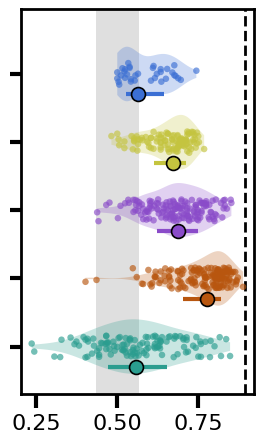

p = 3, 500 shots: r_ideal = 0.895, random band 0.500 ± 0.067 (3 sigma)
    iqm_garnet: n= 35  median 0.564  IQR [0.527, 0.643]  range [0.500, 0.744]
   iqm_emerald: n=104  median 0.672  IQR [0.612, 0.710]  range [0.482, 0.768]
  ibm_kingston: n=148  median 0.686  IQR [0.622, 0.748]  range [0.438, 0.852]
    ibm_boston: n=148  median 0.778  IQR [0.703, 0.821]  range [0.402, 0.888]
   ibm_phoenix: n=120  median 0.558  IQR [0.471, 0.653]  range [0.236, 0.848]


In [3]:
DEPTH_3C = 3
triplet_r = {d: np.array(sorted(by[DEPTH_3C]["r"] for by in sweeps[d].values() if DEPTH_3C in by)) for d in TRIPLET_RUNS}
S = sweeps["ibm_boston"][next(iter(sweeps["ibm_boston"]))][DEPTH_3C]["shots"]
sigma = random_sigma(S)

fig, ax = plt.subplots(figsize=(3, 5))
rng = np.random.default_rng(0)
rows = list(TRIPLET_RUNS)[::-1]        # first device on top
for y, device in enumerate(rows):
    v, colour = triplet_r[device], COLOURS[device]
    for body in ax.violinplot([v], positions=[y], vert=False, widths=0.8, showextrema=False,
                              showmedians=False)["bodies"]:
        body.set_facecolor(colour); body.set_alpha(0.25); body.set_edgecolor("none")
    ax.scatter(v, y + rng.uniform(-0.16, 0.16, v.size), s=22, color=colour, alpha=0.65, edgecolors="none", zorder=3)
    q1, med, q3 = np.quantile(v, [0.25, 0.5, 0.75])
    ax.plot([q1, q3], [y - 0.3] * 2, color=colour, lw=3, solid_capstyle="butt", zorder=4)
    ax.plot([med], [y - 0.3], marker="o", ms=10, color=colour, zorder=5, markeredgecolor="black")
ax.axvspan(0.5 - 3 * sigma, 0.5 + 3 * sigma, color="gray", alpha=0.25, lw=0, zorder=0)
ax.axvline(noiseless(DEPTH_3C), ls="--", lw=2, color="black", zorder=1)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([d.replace("_", " ") for d in rows] if SHOW_LABELS else [""] * len(rows))
ax.set_ylim(-0.7, len(rows) - 0.05)
if SHOW_LABELS:
    ax.set_xlabel("approximation ratio $r$")
fig.savefig(FIGURES / f"fig3c_mcm_r_distribution_p{DEPTH_3C}.pdf", transparent=True, bbox_inches="tight")
plt.show()

print(f"p = {DEPTH_3C}, {S} shots: r_ideal = {noiseless(DEPTH_3C):.3f}, random band 0.500 ± {3 * sigma:.3f} (3 sigma)")
for device, v in triplet_r.items():
    print(f"{device:>14}: n={len(v):>3}  median {np.median(v):.3f}  IQR [{np.quantile(v, .25):.3f}, "
          f"{np.quantile(v, .75):.3f}]  range [{v.min():.3f}, {v.max():.3f}]")

## 2. Fig. 3d - approximation ratio against depth, over all triplets

**What it shows.** For each device, the median $r$ over all its triplets at $p = 3, 6, 9, 12$, with the
inter-quartile range as error bars (a small horizontal offset keeps the devices apart). The dashed line is
the noiseless $r_{\rm ideal}(p)$, which rises with depth, and the grey band is random guessing. On a perfect
device the points would follow the dashed line upwards. The gap to it, and whether it grows with $p$, is
the accumulated cost of one more measure-and-correct cycle per layer.

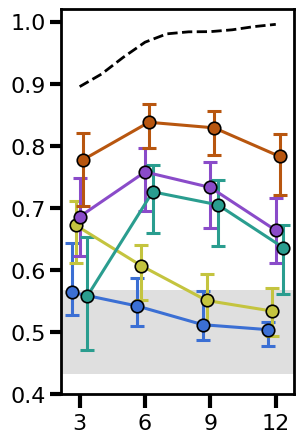

        device                p=3                p=6                p=9               p=12
    iqm_garnet    0.564 -0.037+0.079    0.542 -0.032+0.046    0.512 -0.024+0.054    0.504 -0.027+0.012
   iqm_emerald    0.672 -0.060+0.038    0.607 -0.055+0.034    0.551 -0.039+0.043    0.534 -0.040+0.036
  ibm_kingston    0.686 -0.064+0.062    0.758 -0.063+0.038    0.733 -0.066+0.041    0.664 -0.053+0.052
    ibm_boston    0.778 -0.075+0.042    0.838 -0.042+0.030    0.829 -0.044+0.027    0.783 -0.061+0.035
   ibm_phoenix    0.558 -0.087+0.095    0.726 -0.067+0.042    0.705 -0.066+0.039    0.636 -0.075+0.036


In [4]:
DEPTHS_3D = [3, 6, 9, 12]
stats = {}
for device in TRIPLET_RUNS:
    for p in DEPTHS_3D:
        v = np.array([by[p]["r"] for by in sweeps[device].values() if p in by])
        q1, mid, q3 = np.quantile(v, [0.25, 0.5, 0.75])
        stats.setdefault(device, []).append((p, mid, mid - q1, q3 - mid, len(v)))

fig, ax = plt.subplots(figsize=(3, 5))
ax.axhspan(0.5 - 3 * sigma, 0.5 + 3 * sigma, color="gray", alpha=0.25, lw=0, zorder=0, label="random $3\\sigma$")
fine = np.arange(min(DEPTHS_3D), max(DEPTHS_3D) + 1)
ax.plot(fine, [noiseless(p) for p in fine], ls="--", lw=2, color="black", zorder=1, label="noiseless")
for dx, device in zip(np.linspace(-0.35, 0.35, len(TRIPLET_RUNS)), TRIPLET_RUNS):
    p, mid, lo, hi, n = np.array(stats[device]).T
    ax.errorbar(p + dx, mid, yerr=[lo, hi], color=COLOURS[device], lw=2.2, marker="o", ms=9,
                markeredgecolor="black", capsize=5, capthick=2.2, elinewidth=2.2, zorder=3,
                label=device.replace("_", " "))
ax.set_xticks(DEPTHS_3D)
ax.set_ylim(0.4, 1.02)
if SHOW_LABELS:
    ax.set(xlabel="$p$", ylabel="approximation ratio $r$")
    ax.legend(fontsize=10, loc="upper center", bbox_to_anchor=(0.5, 1.4), ncol=2)
fig.savefig(FIGURES / "fig3d_mcm_r_vs_p_median.pdf", transparent=True, bbox_inches="tight")
plt.show()

print(f"{'device':>14} " + " ".join(f"{'p=' + str(p):>18}" for p in DEPTHS_3D))
for device in TRIPLET_RUNS:
    print(f"{device:>14} " + " ".join(f"{mid:>8.3f} -{lo:.3f}+{hi:.3f}" for _, mid, lo, hi, _ in stats[device]))

## 3. Fig. 3e - the best triplet of each device, against depth

**What it shows.** Fig. 3c-3d describe whole chips. This panel asks how good the gadget can be at all: one
curve per device for its single best triplet, and the same circuit on Quantinuum's Helios-1E emulator, where
the ancilla is allocated freely on an all-to-all machine, for scale. The dashed line is the noiseless
$r_{\rm ideal}(p)$ and the grey band random guessing.

**Which triplet is "best".** The one with the highest $r_{\rm ovl}$ at $p = 3$, among triplets measured at
three or more depths. Its whole sweep is then drawn. Choosing by one depth is a statement about that depth:
the winners sit well above their device's median, but the ranking over the full sweep can differ (on
Boston, the $p = 3$ winner is not the best triplet over all depths). The table below gives each winner's
shot-noise uncertainty and how many other triplets are within it (`ties`). Where `ties` is not zero, the
choice of winner is not resolved at 500 shots.

Devices shown: Helios-1E, IQM Garnet, IQM Emerald, IBM Kingston and IBM Boston, as in the published panel.
IBM Phoenix was measured after that panel was made; add it to `FIG3EF_DEVICES` to include it.

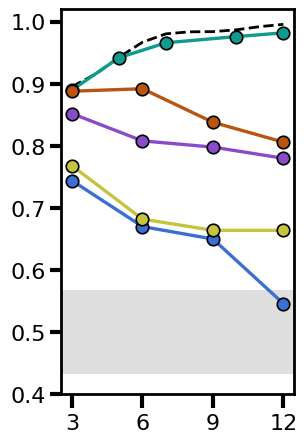

best triplet = highest r_ovl at p = 3

       device  triplet (d1, a, d2)  r_ovl  sigma  ties   r by depth
    Helios-1E            (0, 2, 1)  0.986  0.035     0   p3=0.890  p5=0.942  p7=0.966  p10=0.976  p12=0.982
   iqm_garnet         (15, 14, 18)  0.617  0.049     0   p3=0.744  p6=0.670  p9=0.650  p12=0.546
  iqm_emerald         (35, 34, 42)  0.678  0.048     2   p3=0.768  p6=0.682  p9=0.664  p12=0.664
 ibm_kingston      (147, 148, 149)  0.890  0.040     2   p3=0.852  p6=0.808  p9=0.798  p12=0.780
   ibm_boston      (136, 143, 142)  0.981  0.036     0   p3=0.888  p6=0.892  p9=0.838  p12=0.806


In [5]:
FIG3EF_DEVICES = ["Helios-1E", "iqm_garnet", "iqm_emerald", "ibm_kingston", "ibm_boston"]
SCORE_DEPTH = 3


def score(by):
    s = by[SCORE_DEPTH]
    return s["r_ovl"], np.sqrt(s["r"] * (1 - s["r"]) / s["shots"]) / (s["r_ideal"] - 0.5)


best = {}
for device in FIG3EF_DEVICES:
    candidates = sorted(((score(by)[0], chain.qubits, chain) for chain, by in sweeps[device].items()
                         if SCORE_DEPTH in by and len(by) >= 3), reverse=True)
    value, _, chain = candidates[0]
    sigma_score = score(sweeps[device][chain])[1]
    ties = sum(1 for other, _, _ in candidates[1:] if other > value - sigma_score)
    best[device] = dict(chain=chain, by=sweeps[device][chain], score=value, sigma=sigma_score, ties=ties)

fig, ax = plt.subplots(figsize=(3, 5))
all_p = sorted({p for b in best.values() for p in b["by"]})
fine = np.arange(min(all_p), max(all_p) + 1)
ax.plot(fine, [noiseless(p) for p in fine], "--", lw=2, color="black", zorder=2, label="noiseless")
ax.axhspan(0.5 - 3 * sigma, 0.5 + 3 * sigma, color="gray", alpha=0.25, lw=0, zorder=0, label="random $3\\sigma$")
for device, b in best.items():
    ps = sorted(b["by"])
    ax.plot(ps, [b["by"][p]["r"] for p in ps], "o-", ms=9, lw=2.4, markeredgecolor="black",
            color=COLOURS[device], zorder=3, label=device.replace("_", " "))
ax.set_xticks([3, 6, 9, 12])
ax.set_ylim(0.4, 1.02)
if SHOW_LABELS:
    ax.set(xlabel="$p$", ylabel="approximation ratio $r$")
    ax.legend(fontsize=10, loc="lower left")
fig.savefig(FIGURES / "fig3e_mcm_best_triplet_r.pdf", transparent=True, bbox_inches="tight")
plt.show()

print(f"best triplet = highest r_ovl at p = {SCORE_DEPTH}\n")
print(f"{'device':>13} {'triplet (d1, a, d2)':>20} {'r_ovl':>6} {'sigma':>6} {'ties':>5}   r by depth")
for device, b in best.items():
    print(f"{device:>13} {str(b['chain'].qubits):>20} {b['score']:>6.3f} {b['sigma']:>6.3f} {b['ties']:>5}   "
          + "  ".join(f"p{p}={b['by'][p]['r']:.3f}" for p in sorted(b["by"])))

## 4. Fig. 3f - the best triplets as normalised quality

**What it shows.** The triplets of Fig. 3e as $r_{\rm ovl} = (r - r_{\rm rand})/(r_{\rm ideal} - r_{\rm rand})$, which
divides out the ramp: a noiseless device sits on the dashed line at 1 at every depth, and 0 is random
guessing. The decay of each curve is what the measure-and-correct cycle costs as layers accumulate.

**Significance.** A point is drawn as a filled circle only if $r > r_{\rm rand} + 3\sigma_{\rm rand}$ for that run's
shots, i.e. significantly better than random sampling. A point that fails this is drawn as an ✕ on a dashed
continuation, so the sweep stays visible without being read as a measurement. The grey region is the
same threshold in $r_{\rm ovl}$ units, $3\sigma_{\rm rand} / (r_{\rm ideal}(p) - 1/2)$, which shrinks with depth as
$r_{\rm ideal}$ grows. Anything inside it cannot be told apart from random.

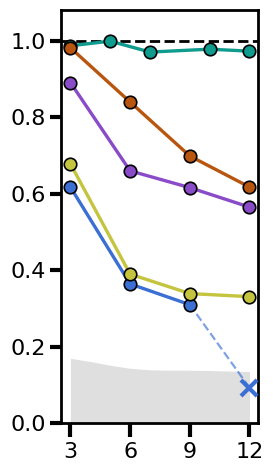

✕ iqm_garnet p=12: r = 0.546 <= random + 3 sigma = 0.567 (drawn, but not a measurement)
random threshold: r > 0.567; in r_ovl 0.170 at p=3 down to 0.135 at p=12


In [6]:
fig, ax = plt.subplots(figsize=(3, 5))
failed = []
for device, b in best.items():
    colour, ps = COLOURS[device], sorted(b["by"])
    ys = np.array([b["by"][p]["r_ovl"] for p in ps])
    ok = np.array([b["by"][p]["r"] > 0.5 + 3 * random_sigma(b["by"][p]["shots"]) for p in ps])
    failed += [(device, p, b["by"][p]["r"], 0.5 + 3 * random_sigma(b["by"][p]["shots"]))
               for p, passed in zip(ps, ok) if not passed]
    ps = np.array(ps)
    if not ok.all():
        ax.plot(ps, ys, "--", lw=1.6, alpha=0.65, color=colour, zorder=2)
    ax.plot(ps[ok], ys[ok], "o-", ms=9, lw=2.4, markeredgecolor="black", color=colour, zorder=3,
            label=device.replace("_", " "))
    ax.plot(ps[~ok], ys[~ok], "x", ms=11, mew=3, color=colour, zorder=4)

fine = np.arange(3, 13)
threshold = 3 * sigma / (np.array([noiseless(p) for p in fine]) - 0.5)
ax.fill_between(fine, 0, threshold, color="gray", alpha=0.25, lw=0, zorder=0)
ax.axhline(1.0, ls="--", lw=2, color="black", zorder=1)
ax.set_xticks([3, 6, 9, 12])
ax.set_ylim(0, 1.08)
if SHOW_LABELS:
    ax.set(xlabel="$p$", ylabel=r"$r_{\rm ovl}$")
    ax.legend(fontsize=10, loc="lower left")
fig.tight_layout()
fig.savefig(FIGURES / "fig3f_mcm_best_triplet_rovl.pdf", transparent=True, bbox_inches="tight")
plt.show()

for device, p, r, limit in failed:
    print(f"✕ {device} p={p}: r = {r:.3f} <= random + 3 sigma = {limit:.3f} (drawn, but not a measurement)")
print(f"random threshold: r > {0.5 + 3 * sigma:.3f}; in r_ovl {threshold[0]:.3f} at p=3 down to {threshold[-1]:.3f} at p=12")

## 5. Fig. 4 - effective error per edge against chain length: Helios-1 and IBM Boston

**What it shows.** For MCM chains of $N_q$ spins, the effective error per edge $\lambda_{\rm eff}$: the two-qubit
depolarizing strength per edge interaction that reproduces the measured decay,

$$r_{\rm ovl}(p) = 2^{-(\kappa_0/N_q)\,(N_q-1)\,p\,\lambda_{\rm eff}} ,$$

with $\kappa_0$ from the depolarizing simulation of `noise_study.ipynb` (`data/noise_study/kappa_fits.json`).
Squares are Helios-1 hardware (50 shots), circles IBM Boston (1000 shots). Lower is better. A flat curve means
each edge costs the same however long the chain, and a rising one means longer chains cost more per edge.

**Why the serialized Helios-1 runs are worse.** Every Helios-1 run before September (grey: 9 March at
$N_q = 40$, 25 May at $N_q = 30$, 26 May at $N_q = 50$; purple: 25 August at $N_q = 30, 40, 50$) built each layer
with the serial program `qaoa_mcm`. It emits the $N_q - 1$ gadgets bond by bond, and gadget $i+1$ shares a data
qubit with gadget $i$, so it has to wait for gadget $i$'s measurement and correction. A layer is then a chain of
$N_q - 1$ dependent measure-and-correct steps. The data qubits sit idle through all of them, so the memory error
per layer grows with the chain length, and the fit charges it to every edge. The 9 September runs (orange) use
the parallel program `qaoa_mcm_parallel` (the program `benchmark_quantinuum.ipynb` submits in this repository).
It runs the even bonds, then the odd bonds, with the gadgets of a class on disjoint qubits, so none waits on its
neighbour, and at most 8 run at once in Helios-1's operation zones.

The 25 August and 9 September campaigns run the same chains, depths and shots, two weeks apart, so the step
between them isolates the ordering: $\lambda_{\rm eff}$ drops 3.1x, 2.5x and 3.4x at $N_q = 30, 40, 50$ (printed
below). The grey curve is serialized too, so the further ~2x between it and 25 August (1.9x, 1.9x, 2.3x) is not
the ordering. Those runs are three to five months apart, and the gap most likely reflects improvements in the
machine's calibration over that time (no calibration record of these runs is kept to confirm it).

*Provenance of the orderings.* The serial program is what the Quantinuum notebook of the earlier repository
contained for the May runs (commit of 26 May 2026, whose saved output is the 25 May run). The 25 August runs were
serialized as well; the fit files of that repository record them as "colour?", which is wrong. The parallel program
first appears in the commit of 1 September. The 9 September runs are recorded as the two-colour ordering, and the
15 September run is known to use it.

**IBM Boston.** On 25 August each size used its own layout chosen at submission. The 27 and 31 August
campaigns are pinned to the same chain of physical qubits, so the gap between them is run-to-run
repeatability. All three use the two-colour ordering.

**Fits.** Helios-1 over $p = 3, 5, 10$ (all it ran), Boston over $p = 10\ldots50$, where its decay is closest to
a pure exponential. Each device is therefore compared only with itself. Points at or below random are
dropped. Fitted values only, no error bars: with 3-6 points per fit the curve-fit covariance reflects the
number of points more than the measurement.

| series | runs in `data/results/<backend>/chain/mcm/` |
|---|---|
| Helios-1, earlier (serial) | `20260309_0726` ($N_q = 40$, 20 shots), `20260525_0955` (30), `20260526_0735` (50) |
| Helios-1, 08-25 (serial) | `20260825_1505` (30), `20260825_1540` + `_1541` (40), `20260825_1542` + `_1543` + `_1606` (50) |
| Helios-1, 09-09 (parallel) | `20260909_1423` (30), `20260909_1509` (40), `20260909_1521` (50) |
| ibm_boston, 08-25 | `20260825_1618` (10), `_1619` (20), `_1620` (30, 40), `_1621` (50), `_1629` (60) |
| ibm_boston, 08-27 | `20260827_1035` ($N_q = 10\ldots60$) |
| ibm_boston, 08-31 | `20260831_1122` ($N_q = 10\ldots60$) |

**Difference from the first version of the figure.** Every $\lambda_{\rm eff}$ is 0.95x the published value,
the ratio of the two $\kappa_0$: 3.69 from the per-edge simulation here, against 3.51 fitted earlier with a
per-CNOT error. The references are exact here, and at these sizes that moves no value by more than 2%.
The shapes and the ordering of the curves are unchanged.

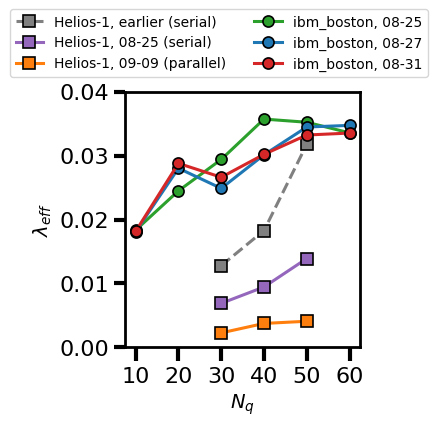

kappa_0 = 3.689; lambda_eff per edge

                                     10         20         30         40         50         60
Helios-1, earlier (serial)            -          -  1.277e-02  1.827e-02  3.179e-02          -
Helios-1, 08-25 (serial)              -          -  6.867e-03  9.432e-03  1.389e-02          -
Helios-1, 09-09 (parallel)            -          -  2.242e-03  3.721e-03  4.063e-03          -
ibm_boston, 08-25             1.833e-02  2.449e-02  2.941e-02  3.573e-02  3.523e-02  3.357e-02
ibm_boston, 08-27             1.809e-02  2.803e-02  2.487e-02  3.013e-02  3.449e-02  3.474e-02
ibm_boston, 08-31             1.814e-02  2.879e-02  2.662e-02  3.020e-02  3.323e-02  3.354e-02

Helios-1, earlier (serial)   grows 2.5x from N_q = 30 to 50
Helios-1, 08-25 (serial)     grows 2.0x from N_q = 30 to 50
Helios-1, 09-09 (parallel)   grows 1.8x from N_q = 30 to 50
ibm_boston, 08-25            grows 1.8x from N_q = 10 to 60
ibm_boston, 08-27            grows 1.9x from N_q = 10 to

In [7]:
import json

from qecbench.noise_study import fit_lambda_eff

KAPPA_0 = json.loads((ROOT / "data" / "noise_study" / "kappa_fits.json").read_text())["kappa_0"]["value"]
HELIOS_WINDOW, BOSTON_WINDOW = [3, 5, 10], [10, 15, 20, 30, 40, 50]
FIG4_SERIES = [   # legend, backend, run stamps, fit window, colour, marker, linestyle
    ("Helios-1, earlier (serial)", "Helios-1", ["20260309_0726", "20260525_0955", "20260526_0735"],
     HELIOS_WINDOW, "grey", "s", "--"),
    ("Helios-1, 08-25 (serial)", "Helios-1", ["20260825_1505", "20260825_1540", "20260825_1541", "20260825_1542",
                                     "20260825_1543", "20260825_1606"], HELIOS_WINDOW, "tab:purple", "s", "-"),
    ("Helios-1, 09-09 (parallel)", "Helios-1", ["20260909_1423", "20260909_1509", "20260909_1521"],
     HELIOS_WINDOW, "tab:orange", "s", "-"),
    ("ibm_boston, 08-25", "ibm_boston", ["20260825_1618", "20260825_1619", "20260825_1620", "20260825_1621",
                                         "20260825_1629"], BOSTON_WINDOW, "tab:green", "o", "-"),
    ("ibm_boston, 08-27", "ibm_boston", ["20260827_1035"], BOSTON_WINDOW, "tab:blue", "o", "-"),
    ("ibm_boston, 08-31", "ibm_boston", ["20260831_1122"], BOSTON_WINDOW, "tab:red", "o", "-"),
]

lambda_by_nq = {}
for legend, backend, stamps, window, *_ in FIG4_SERIES:
    fits = {}
    for chain, by_depth in runs(backend, stamps, kind="mcm").items():
        n = chain.n_data
        ps = np.array([p for p in window if p in by_depth], dtype=float)
        ovl = np.array([by_depth[int(p)]["r_ovl"] for p in ps])
        keep = ovl > 0
        if keep.sum() >= 2:
            fits[n] = fit_lambda_eff(ps[keep], ovl[keep], n - 1, KAPPA_0 / n)["lambda_eff"]
    lambda_by_nq[legend] = dict(sorted(fits.items()))

fig, ax = plt.subplots(figsize=(4, 5))
for legend, _, _, _, colour, marker, ls in FIG4_SERIES:
    fits = lambda_by_nq[legend]
    ax.plot(list(fits), list(fits.values()), marker=marker, color=colour, linestyle=ls, markersize=8,
            markeredgecolor="black", label=legend)
ax.set_xlabel(r"$N_q$", fontsize=14)
ax.set_ylabel(r"$\lambda_{eff}$", fontsize=14)
ax.set_yticks([0.0, 0.01, 0.02, 0.03, 0.04])
ax.set_xticks(sorted({n for fits in lambda_by_nq.values() for n in fits}))
ax.legend(fontsize=10, loc="upper center", bbox_to_anchor=(0.4, 1.35), ncols=2)
plt.tight_layout()
fig.savefig(FIGURES / "fig4_lambda_eff_old_vs_new.pdf", transparent=True, bbox_inches="tight")
plt.show()

sizes = sorted({n for fits in lambda_by_nq.values() for n in fits})
print(f"kappa_0 = {KAPPA_0:.3f}; lambda_eff per edge\n")
print(f"{'':<28}" + "".join(f"{n:>11}" for n in sizes))
for legend, fits in lambda_by_nq.items():
    print(f"{legend:<28}" + "".join(f"{fits[n]:>11.3e}" if n in fits else f"{'-':>11}" for n in sizes))
print()
for legend, fits in lambda_by_nq.items():
    lo, hi = min(fits), max(fits)
    print(f"{legend:<28} grows {fits[hi] / fits[lo]:.1f}x from N_q = {lo} to {hi}")
earlier, august, parallel = (lambda_by_nq[k] for k in ("Helios-1, earlier (serial)", "Helios-1, 08-25 (serial)",
                                                        "Helios-1, 09-09 (parallel)"))
print("\nHelios-1, the ordering (08-25 serial / 09-09 parallel):  "
      + ", ".join(f"N_q = {n}: {august[n] / parallel[n]:.1f}x" for n in august if n in parallel))
print("Helios-1, calibration over time (earlier serial / 08-25 serial): "
      + ", ".join(f"N_q = {n}: {earlier[n] / august[n]:.1f}x" for n in earlier if n in august))

## 6. Fig. 5 - the noise model, and effective errors from it

Fig. 5 turns measured overlaps into an effective error per edge, $\lambda_{\rm eff}$. Panels a-c are redrawn
from `notebooks/noise_study.ipynb` (sections 4, 6 and 7): the model, its calibration on a 10-spin chain, and
$\lambda_{\rm eff}$ across devices and chain lengths. Panel d sets the devices against their release dates.

**The model.** Put a two-qubit depolarizing channel of strength $\lambda$ after every edge interaction of an
$N_q$-spin chain run at depth $p$. The overlap then falls on

$$r_{\rm ovl} = 2^{-\kappa_r\,\varepsilon_{\rm acc}},\qquad \varepsilon_{\rm acc} = N_{\rm edges}\,p\,\lambda,\qquad \kappa_r = \kappa_0/N_q ,$$

with $N_{\rm edges} = N_q - 1$. Inverting it on a device's overlaps, with $\kappa$ held fixed, gives
$\lambda_{\rm eff}$. The simulation behind $\kappa_0$ is exact in expectation and uses no density matrix; its
tables are stored in `data/noise_study/chain_depolarizing.json`, so these panels need no simulation.

### Fig. 5a - $\kappa_r$ for each chain length, and $\kappa_0$

Left: the approximation-ratio overlap against $\varepsilon_{\rm acc}$, one colour per $N_q = 5\ldots15$, all
depths ($p = 2, 5, 10$) together. Every depth of a size lands on one curve, and the lines are the
per-size fits $2^{-\kappa_r\varepsilon_{\rm acc}}$. Right: the fitted $\kappa_r$ against $N_q$ ($3\sigma$ error bars)
and the one-parameter law $\kappa_r = \kappa_0/N_q$.

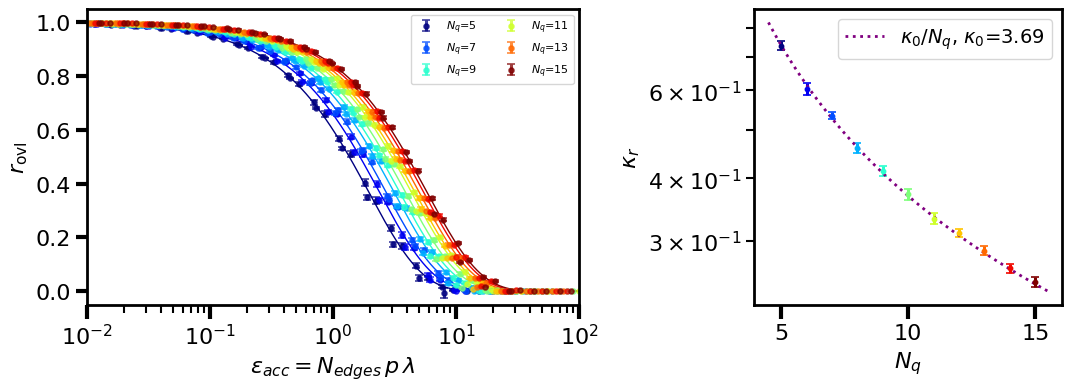

kappa_0 = 3.689 ± 0.012   (kappa_r = kappa_0 / N_q)


In [8]:
import json

from qecbench.noise_study import (accumulated_error, collapse, device_overlaps, device_run, fit_kappa,
                                  fit_kappa0, fit_lambda_eff, load_study, overlap_model)

STUDY = load_study(ROOT / "data" / "noise_study" / "chain_depolarizing.json")
NQS, STUDY_DEPTHS, LAMBDAS = list(range(5, 16)), [2, 5, 10], np.logspace(-5, 0, 25)
study = {key: d for key, d in STUDY.items() if key[1] in STUDY_DEPTHS}

fits_r = {n: fit_kappa(*collapse(study, n, LAMBDAS, "r")[:2]) for n in NQS}
KAPPA_0, kappa0_err, _ = fit_kappa0(NQS, [fits_r[n]["kappa"] for n in NQS])

cmap = plt.get_cmap("jet")
size_colour = {n: cmap(i / max(len(NQS) - 1, 1)) for i, n in enumerate(NQS)}
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
x = np.logspace(-2, 2, 300)
for n in NQS:
    eps, ovl, err, depth, tail = collapse(study, n, LAMBDAS, "r")
    keep = (eps >= 1e-2) & (eps <= 1e2)
    ax.errorbar(eps[keep], ovl[keep], yerr=err[keep], fmt="o", ms=3.5, color=size_colour[n], alpha=0.75,
                label=f"$N_q$={n}" if n % 2 else None)
    ax.plot(x, overlap_model(x, fits_r[n]["kappa"]), color=size_colour[n], lw=1)
ax.set(xscale="log", xlim=(1e-2, 1e2), ylim=(-0.05, 1.05), xlabel=r"$\varepsilon_{acc} = N_{edges}\,p\,\lambda$",
       ylabel=r"$r_{\rm ovl}$")
ax.legend(fontsize=8, ncol=2)
dense = np.linspace(min(NQS) - 0.5, max(NQS) + 0.5, 200)
for n in NQS:
    bx.errorbar(n, fits_r[n]["kappa"], yerr=3 * fits_r[n]["stderr"], fmt="o", color=size_colour[n], capsize=3)
bx.plot(dense, KAPPA_0 / dense, ":", color="purple", lw=2, label=fr"$\kappa_0/N_q$, $\kappa_0$={KAPPA_0:.2f}")
bx.set(yscale="log", xlabel="$N_q$", ylabel=r"$\kappa_r$")
bx.legend()
fig.tight_layout()
fig.savefig(FIGURES / "fig5a_kappa_r_scaling.pdf", transparent=True, bbox_inches="tight")
plt.show()
print(f"kappa_0 = {KAPPA_0:.3f} ± {kappa0_err:.3f}   (kappa_r = kappa_0 / N_q)")

### Fig. 5b - $\lambda_{\rm eff}$ of a 10-spin chain on IBM Boston and Helios-1E

Grey: the depolarizing simulation at $N_q = 10$ over the depths the devices ran ($p = 10\ldots50$), and its
fit. Coloured: device overlaps, each placed at $\varepsilon_{\rm acc} = 9\,p\,\lambda_{\rm eff}$ with its fitted
$\lambda_{\rm eff}$; circles are the direct circuit, triangles MCM. Left, the approximation ratio with
$\kappa_r = \kappa_0/10$; right, the probability of the optimum with $\kappa_\rho$ fitted at these depths.
Points that follow the grey curve degrade like uniform depolarizing noise.

**Data.** `data/results/ibm_boston/chain/{direct,mcm}/`: `20260506_1507` (direct) and `20260506_1537` (MCM),
10 000 shots, $p = 10\ldots50$. `data/results/Helios-1E/chain/{direct,mcm}/`: `20260507_0900` (direct) and
`20260508_0700` (MCM), 1 000 shots on **Quantinuum's Helios-1E emulator** (flagged as simulated),
$p = 1\ldots10, 15, 20, 30, 40, 50$. Overlaps above 1.2 (shot noise on nearly noiseless points) are set to 1.

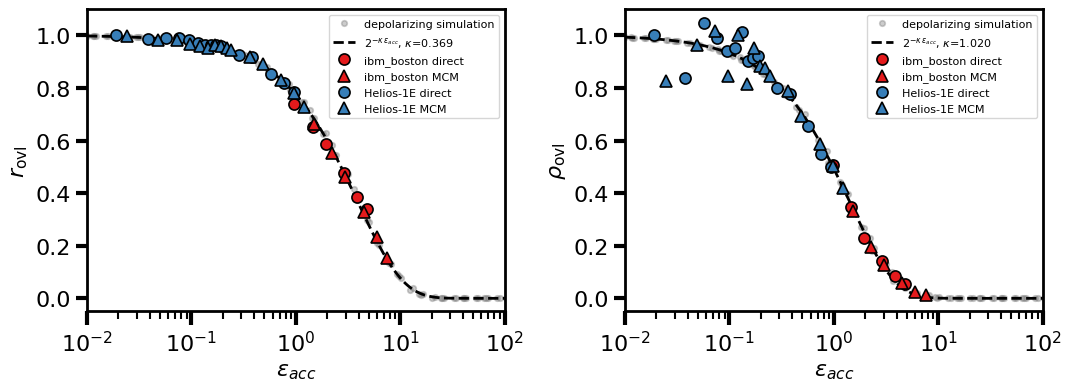

kappa_r = 0.369, kappa_rho = 1.020 (p = [10, 20, 30, 40, 50])

                       lambda_eff from r    from rho
ibm_boston direct               1.08e-02    1.08e-02
ibm_boston MCM                  1.66e-02    1.68e-02
Helios-1E direct                2.12e-03    2.09e-03
Helios-1E MCM                   2.68e-03    2.71e-03


In [9]:
DEVICE_N, DEEP_DEPTHS = 10, [10, 20, 30, 40, 50]
FIG5B_RUNS = {   # label -> (backend, kind, run stamps, depths)
    ("ibm_boston", "direct"): ("ibm_boston", "direct", ["20260506_1507"], [10, 15, 20, 30, 40, 50]),
    ("ibm_boston", "MCM"):    ("ibm_boston", "mcm", ["20260506_1537"], [10, 15, 20, 30, 40, 50]),
    ("Helios-1E", "direct"):  ("Helios-1E", "direct", ["20260507_0900"], [*range(1, 11), 15, 20, 30, 40, 50]),
    ("Helios-1E", "MCM"):     ("Helios-1E", "mcm", ["20260508_0700"], [*range(1, 11), 15, 20, 30, 40, 50]),
}
deep = {key: d for key, d in STUDY.items() if key[0] == DEVICE_N and key[1] in DEEP_DEPTHS}
kappa_rho = fit_kappa(*collapse(deep, DEVICE_N, LAMBDAS, "prob")[:2])["kappa"]
kappas = {"r": KAPPA_0 / DEVICE_N, "prob": kappa_rho}
set1 = plt.get_cmap("Set1")
device_colour, marker = {"ibm_boston": set1(0), "Helios-1E": set1(1)}, {"direct": "o", "MCM": "^"}

lambda_5b = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, observable, ylabel in zip(axes, ("r", "prob"), (r"$r_{\rm ovl}$", r"$\rho_{\rm ovl}$")):
    eps, ovl, *_ = collapse(deep, DEVICE_N, LAMBDAS, observable)
    ax.plot(eps, ovl, "o", color="gray", alpha=0.4, ms=4, label="depolarizing simulation")
    ax.plot(x, overlap_model(x, kappas[observable]), "--", color="black", lw=2,
            label=fr"$2^{{-\kappa\,\varepsilon_{{acc}}}}$, $\kappa$={kappas[observable]:.3f}")
    for (device, circuit), (backend, kind, stamps, depths) in FIG5B_RUNS.items():
        ps, values = device_overlaps(device_run(RESULTS, backend, kind, stamps, DEVICE_N, depths), DEVICE_N,
                                     observable=observable)
        fit = fit_lambda_eff(ps, values, DEVICE_N - 1, kappas[observable])
        lambda_5b[(device, circuit, observable)] = fit["lambda_eff"]
        ax.plot(accumulated_error(DEVICE_N - 1, ps, fit["lambda_eff"]), values, marker[circuit], ms=8,
                color=device_colour[device], mec="black", label=f"{device} {circuit}")
    ax.set(xscale="log", xlim=(1e-2, 1e2), ylim=(-0.05, 1.1), xlabel=r"$\varepsilon_{acc}$", ylabel=ylabel)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "fig5b_lambda_eff_nq10.pdf", transparent=True, bbox_inches="tight")
plt.show()

print(f"kappa_r = {kappas['r']:.3f}, kappa_rho = {kappa_rho:.3f} (p = {DEEP_DEPTHS})\n")
print(f"{'':<20}{'lambda_eff from r':>20}{'from rho':>12}")
for device, circuit in FIG5B_RUNS:
    print(f"{device + ' ' + circuit:<20}{lambda_5b[(device, circuit, 'r')]:>20.2e}{lambda_5b[(device, circuit, 'prob')]:>12.2e}")

### Fig. 5c - $\lambda_{\rm eff}$ against chain length, across devices

The per-edge $\lambda_{\rm eff}$ of every device at every chain length it ran, for the direct circuit (circles,
solid lines) and the MCM circuit (crosses, dashed lines), with $\kappa_r = \kappa_0/N_q$ from Fig. 5a. The
chains run to $N_q = 60$, far past the $N_q \le 15$ of the simulation, so the $1/N_q$ law is extrapolated.
Dotted segments are Quantinuum **hardware**, a dotted link joins an emulator point to a hardware point, and the
Helios-1E emulator is left out so that no simulated point looks measured.

| device | direct circuits | MCM circuits |
|---|---|---|
| `ibm_boston`, `ibm_pittsburgh`, `ibm_kingston` | April-May 2026, $N_q = 10\ldots60$ | late August 2026, $N_q = 10\ldots60$ |
| Quantinuum Helios | Helios-1 hardware, $N_q = 30, 40, 50$ | Helios-1 hardware: $N_q = 20$ (15 September), $30, 40, 50$ (9 September) |
| Quantinuum H2 | H2-1E emulator $N_q = 10, 20$; H2-1 hardware $N_q = 30$ | same split, 20 August 2026 |
| `ibm_fez`, `ibm_marrakesh`, `ibm_phoenix` | - | late August / early September 2026 |

**Read the MCM curves against each other.** Every MCM curve here uses the two-colour ordering of the gadgets:
the IBM campaigns, the Helios-1 runs (the parallel program, Fig. 4) and the H2 runs. H2 does not run Guppy, so its
runs were built as pytket circuits (`benchmarking_quantinuum_h2-1.ipynb` in the earlier repository). That builder
colours the bonds into even and odd classes and gives each class a pool of $\lfloor N_q/2 \rfloor$ ancillas, reset and
reused between classes, since H2-1 has a fixed 56-qubit register. Within a class the gadgets touch disjoint data
qubits and disjoint ancillas, so none waits on another. The stored runs carry exactly those pools (5, 10 and 15
ancillas at $N_q = 10, 20, 30$), which confirms the colouring was used. The direct campaigns come from an earlier
period, and no direct runs were made alongside the new MCM ones.

**Fit windows.** MCM: $p = 3, 5, 10$, the only depths every device ran (Helios-1 stops at $p = 10$). This window
inflates $\lambda_{\rm eff}$ by roughly 1.2-1.5x against a $p \ge 10$ window, alike for every device. Direct:
every depth run among $3\ldots50$, after dropping the leading plateau (points up to the maximum overlap). Points
at or below random are dropped. There are no error bars: with 2-8 points per fit the curve-fit covariance
reflects how many points survived, not the measurement.

| device | circuit | runs in `data/results/<backend>/chain/<kind>/` |
|---|---|---|
| `ibm_boston` | direct | `20260512_1429` (10), `20260428_110845` (20), `_110857` (30), `_110905` (40), `_110915` (50), `20260430_0834` (60) |
| | MCM | `20260827_1035` |
| `ibm_pittsburgh` | direct | `20260512_1402` (10), `20260428_111001` (20), `_110953` (30), `_110944` (40), `_110932` (50), `20260430_1618` (60) |
| | MCM | `20260828_1025` |
| `ibm_kingston` | direct | `20260512_1402` (10), `20260505_0806` (20), `20260505_0805` (30-60) |
| | MCM | `20260827_1205` |
| Helios-1 | direct | `20260525_0957` (30), `20260309_0726` (40), `20260526_0802` (50) |
| | MCM | `20260915_1035` (20), `20260909_1423` (30), `_1509` (40), `_1521` (50) |
| H2-1E / H2-1 | direct | `20260820_0646` (H2-1E, 10, 20), `20260820_0651` (H2-1, 30) |
| | MCM | `20260820_0647` (H2-1E, 10, 20), `20260820_0650` (H2-1, 30) |
| `ibm_fez`, `ibm_marrakesh`, `ibm_phoenix` | MCM | `20260828_1028`, `20260828_1034`, `20260904_1435` |

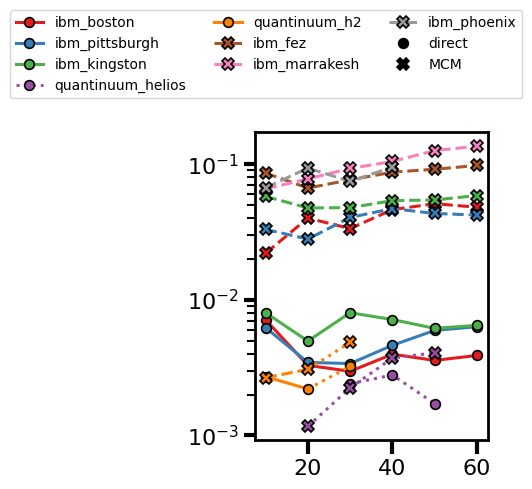

lambda_eff per edge, direct, window p = [3, 5, 10, 15, 20, 30, 40, 50] (leading plateau dropped)
                            10        20        30        40        50        60
ibm_boston            7.12e-03  3.29e-03  2.97e-03  3.97e-03  3.57e-03  3.89e-03
ibm_pittsburgh        6.23e-03  3.46e-03  3.39e-03  4.62e-03  5.95e-03  6.33e-03
ibm_kingston          8.03e-03  4.96e-03  8.03e-03  7.15e-03  6.16e-03  6.49e-03
quantinuum_helios            -         -  2.41e-03  2.79e-03  1.72e-03         -
quantinuum_h2         2.71e-03  2.20e-03  3.23e-03         -         -         -

lambda_eff per edge, mcm, window p = [3, 5, 10]
                            10        20        30        40        50        60
ibm_boston            2.21e-02  4.01e-02  3.36e-02  4.63e-02  5.12e-02  4.82e-02
ibm_pittsburgh        3.31e-02  2.80e-02  4.06e-02  4.71e-02  4.34e-02  4.22e-02
ibm_kingston          5.79e-02  4.76e-02  4.79e-02  5.39e-02  5.45e-02  5.88e-02
quantinuum_helios            -  1.17e-03  2.

In [10]:
from qecbench.noise_study import decaying_part

LAMBDA_SERIES = {   # device -> {circuit: [(backend, run stamp), ...]}
    "ibm_boston":        {"direct": [("ibm_boston", s) for s in ("20260512_1429", "20260428_110845", "20260428_110857",
                                                                  "20260428_110905", "20260428_110915", "20260430_0834")],
                          "mcm":    [("ibm_boston", "20260827_1035")]},
    "ibm_pittsburgh":    {"direct": [("ibm_pittsburgh", s) for s in ("20260512_1402", "20260428_111001", "20260428_110953",
                                                                      "20260428_110944", "20260428_110932", "20260430_1618")],
                          "mcm":    [("ibm_pittsburgh", "20260828_1025")]},
    "ibm_kingston":      {"direct": [("ibm_kingston", s) for s in ("20260512_1402", "20260505_0806", "20260505_0805")],
                          "mcm":    [("ibm_kingston", "20260827_1205")]},
    "quantinuum_helios": {"direct": [("Helios-1", s) for s in ("20260525_0957", "20260309_0726", "20260526_0802")],
                          "mcm":    [("Helios-1", s) for s in ("20260915_1035", "20260909_1423", "20260909_1509", "20260909_1521")]},
    "quantinuum_h2":     {"direct": [("H2-1E", "20260820_0646"), ("H2-1", "20260820_0651")],
                          "mcm":    [("H2-1E", "20260820_0647"), ("H2-1", "20260820_0650")]},
    "ibm_fez":           {"mcm": [("ibm_fez", "20260828_1028")]},
    "ibm_marrakesh":     {"mcm": [("ibm_marrakesh", "20260828_1034")]},
    "ibm_phoenix":       {"mcm": [("ibm_phoenix", "20260904_1435")]},
}
LAMBDA_COLOURS = {"ibm_boston": 0, "ibm_pittsburgh": 1, "ibm_kingston": 2, "quantinuum_helios": 3,
                  "quantinuum_h2": 4, "ibm_fez": 6, "ibm_marrakesh": 7, "ibm_phoenix": 8}   # Set1 indices
QUANTINUUM_HARDWARE = {"Helios-1", "H2-1"}                                                  # drawn dotted
LAMBDA_WINDOWS = {"direct": [3, 5, 10, 15, 20, 30, 40, 50], "mcm": [3, 5, 10]}
DROP_PLATEAU = {"direct": True, "mcm": False}


def lambda_vs_nq(backend, stamps, window, kind="mcm", drop_plateau=False):
    # {N_q: fit} with the per-edge model, kappa = kappa_0 / N_q, over the depths in `window`
    out = {}
    for chain, by_depth in runs(backend, stamps, kind=kind).items():
        n = chain.n_data
        ps = np.array([p for p in window if p in by_depth], dtype=float)
        ovl = np.array([by_depth[int(p)]["r_ovl"] for p in ps])
        ps, ovl = ps[ovl > 0], ovl[ovl > 0]
        if drop_plateau:
            ps, ovl = decaying_part(ps, ovl)
        if len(ps) >= 2:
            out[n] = {**fit_lambda_eff(ps, ovl, n - 1, KAPPA_0 / n), "backend": backend}
    return dict(sorted(out.items()))


lambda_by_nq = {}
for device, kinds in LAMBDA_SERIES.items():
    for kind, device_runs in kinds.items():
        stamps_by_backend = {}
        for backend, stamp in device_runs:
            stamps_by_backend.setdefault(backend, []).append(stamp)
        lambda_by_nq[(device, kind)] = {}
        for backend, stamps in stamps_by_backend.items():
            lambda_by_nq[(device, kind)].update(lambda_vs_nq(backend, stamps, LAMBDA_WINDOWS[kind], kind, DROP_PLATEAU[kind]))

colours = plt.get_cmap("Set1")
style = {"direct": dict(marker="o", ls="-", ms=7), "mcm": dict(marker="X", ls="--", ms=8)}
fig, ax = plt.subplots(figsize=(3, 4))
for device, kinds in LAMBDA_SERIES.items():
    colour = colours(LAMBDA_COLOURS[device])
    labelled = False
    for kind in kinds:
        fits = lambda_by_nq[(device, kind)]
        segments = []                               # consecutive points on the same backend
        for n in sorted(fits):
            if segments and segments[-1][0] == fits[n]["backend"]:
                segments[-1][1].append(n)
            else:
                segments.append((fits[n]["backend"], [n]))
        previous = None
        for backend, nqs in segments:
            ys = [fits[n]["lambda_eff"] for n in nqs]
            ax.plot(nqs, ys, color=colour, mec="black", marker=style[kind]["marker"], ms=style[kind]["ms"],
                    ls=":" if backend in QUANTINUUM_HARDWARE else style[kind]["ls"], label=None if labelled else device)
            labelled = True
            if previous is not None:
                ax.plot([previous[0], nqs[0]], [previous[1], ys[0]], color=colour, ls=":")
            previous = (nqs[-1], ys[-1])
ax.plot([], [], "o", color="black", ms=7, markeredgecolor="black", linestyle="None", label="direct")
ax.plot([], [], "X", color="black", ms=8, markeredgecolor="black", linestyle="None", label="MCM")
ax.set_yscale("log")
if SHOW_LABELS:
    ax.set(xlabel="$N_q$", ylabel=r"$\lambda_{\rm eff}$ per edge")
ax.legend(loc="upper right", fontsize=10, bbox_to_anchor=(1.18, 1.42), ncols=3)
fig.savefig(FIGURES / "fig5c_lambda_eff_by_nq.pdf", transparent=True, bbox_inches="tight")
plt.show()

sizes = sorted({n for fits in lambda_by_nq.values() for n in fits})
for kind in ("direct", "mcm"):
    print(f"lambda_eff per edge, {kind}, window p = {LAMBDA_WINDOWS[kind]}"
          + (" (leading plateau dropped)" if DROP_PLATEAU[kind] else ""))
    print(f"{'':<20}" + "".join(f"{n:>10}" for n in sizes))
    for device in LAMBDA_SERIES:
        fits = lambda_by_nq.get((device, kind))
        if fits:
            print(f"{device:<20}" + "".join(f"{fits[n]['lambda_eff']:>10.2e}" if n in fits else f"{'-':>10}" for n in sizes))
    print()

### Fig. 5d - MCM error per edge against when each device became available

For eight devices, the mean MCM $\lambda_{\rm eff}$ over the chain lengths measured (bars: min-max over $N_q$,
the spread across chain length, not a shot-noise error), placed at the device's first public availability.
Shaded bands cover each vendor's range, and the dashed lines are a guide to the eye: a least-squares line
through $\log_{10}\lambda$ against release date, i.e. a constant factor per year. The two vendors are kept as
separate families. Every IBM superconducting device sits about an order of magnitude above Quantinuum's
trapped-ion machines, so one trend through all points would hide the main result. With 6 IBM points over 4
processor families and 2 Quantinuum points, the trends are anecdotes, not measurements.

**Fits.** $p = 3, 5, 10$ for every device (the only depths every device ran; Helios-1 stops at $p = 10$). The
exception is `ibm_phoenix`, which has no $p = 3$ and reaches the random floor by $p \approx 25$, so it uses
$p = 5, 10, 15, 20$. Two caveats flatter Phoenix: only $N_q = 10\ldots40$ could be embedded cleanly (its
$\lambda_{\rm eff}$ grows with $N_q$), and dropping $p = 3$ alone lowers $\lambda$ by about 1.3x.

**Release dates** are metadata, not data: first public availability as announced by the vendor (`precision`
says whether the date is the system's or only its processor family's, and the source of each is listed).

| device | MCM run(s) in `data/results/<device>/chain/mcm/` | $N_q$ |
|---|---|---|
| `ibm_fez` | `20260828_1028` | 10-60 |
| `ibm_marrakesh` | `20260828_1034` | 10-60 |
| `ibm_kingston` | `20260827_1205` | 10-60 |
| `ibm_pittsburgh` | `20260828_1025` | 10-60 |
| `ibm_boston` | `20260827_1035` | 10-60 |
| `ibm_phoenix` | `20260904_1435` | 10-40 |
| `H2-1` | `20260820_0650` | 30 |
| `Helios-1` | `20260909_1423`, `_1509`, `_1521` | 30-50 |

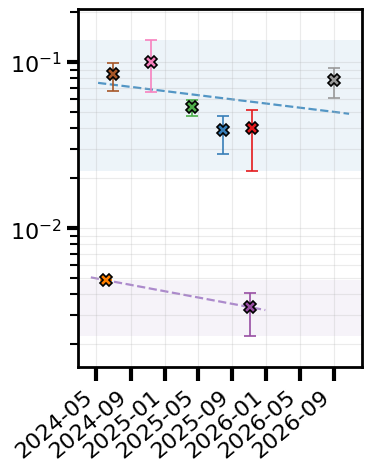

geometric mean lambda_eff (MCM): IBM 6.177e-02, Quantinuum 4.028e-03 -> IBM is 15.3x higher
   IBM         x0.84 per year, R2 = 0.11, n = 6
   Quantinuum  x0.77 per year, R2 = 1.00, n = 2   <- 2 points, the slope is not a measurement

device          first available  processor             precision  window           mean lambda               min - max  N_q
H2-1            2024-06-05       Quantinuum H2 (56q)   system     [3, 5, 10]         4.856e-03   4.856e-03 - 4.856e-03    1
ibm_fez         2024-07-01       Heron r2              month      [3, 5, 10]         8.447e-02   6.681e-02 - 9.792e-02    6
ibm_marrakesh   2024-11-13       Heron r2              system     [3, 5, 10]         1.006e-01   6.585e-02 - 1.358e-01    6
ibm_kingston    2025-04-09       Heron r2              system     [3, 5, 10]         5.344e-02   4.759e-02 - 5.880e-02    6
ibm_pittsburgh  2025-07-31       Heron r3              system     [3, 5, 10]         3.905e-02   2.805e-02 - 4.708e-02    6
Helios-1        2025-

In [11]:
import datetime

import matplotlib.dates as mdates

WINDOW_5D = [3, 5, 10]
DEVICE_INTRO = {   # device -> run stamps, Set1 colour, first availability, processor, precision, source
    "ibm_fez": dict(stamps=["20260828_1028"], c=6, date="2024-07-01", processor="Heron r2", precision="month",
                    source="https://qpustatus.com/ibm-fez"),
    "ibm_marrakesh": dict(stamps=["20260828_1034"], c=7, date="2024-11-13", processor="Heron r2", precision="system",
                          source="https://qpustatus.com/ibm-marrakesh"),
    "ibm_kingston": dict(stamps=["20260827_1205"], c=2, date="2025-04-09", processor="Heron r2", precision="system",
                         source="https://quantum.cloud.ibm.com/announcements/product-updates/2025-04-09-aachen-kingston"),
    "ibm_pittsburgh": dict(stamps=["20260828_1025"], c=1, date="2025-07-31", processor="Heron r3", precision="system",
                           source="https://quantum.cloud.ibm.com/announcements/en/product-updates/2025-07-31-pittsburgh-sherbrooke"),
    "ibm_boston": dict(stamps=["20260827_1035"], c=0, date="2025-11-12", processor="Heron r3", precision="system",
                       note="access expanded 2026-01", source="https://research.ibm.com/events/qdc-2025"),
    "H2-1": dict(stamps=["20260820_0650"], c=4, date="2024-06-05", processor="Quantinuum H2 (56q)", precision="system",
                 source="https://www.quantinuum.com/press-releases/quantinuum-launches-industry-first-trapped-ion-56-qubit-quantum-computer-that-challenges-the-worlds-best-supercomputers"),
    "ibm_phoenix": dict(stamps=["20260904_1435"], c=8, date="2026-09-02", processor="Nighthawk r2", precision="system",
                        window=[5, 10, 15, 20],
                        source="https://quantumcomputingreport.com/ibm-releases-nighthawk-r2-qpu-featuring-active-dissipative-qubit-reset-and-25x-circuit-throughput/"),
    "Helios-1": dict(stamps=["20260909_1423", "20260909_1509", "20260909_1521"], c=3, date="2025-11-05",
                     processor="Quantinuum Helios", precision="system",
                     source="https://thequantuminsider.com/2025/11/05/quantinuum-announces-commercial-launch-of-helios-a-quantum-computer-with-accuracy-to-enable-generative-quantum-ai/"),
}
VENDORS = {"IBM": ("IBM (superconducting)", "tab:blue"), "Quantinuum": ("Quantinuum (trapped ion)", "tab:purple")}

rows = []
for device, info in DEVICE_INTRO.items():
    window = info.get("window", WINDOW_5D)
    values = np.array([f["lambda_eff"] for f in lambda_vs_nq(device, info["stamps"], window).values()])
    rows.append(dict(dev=device, vendor="IBM" if device.startswith("ibm_") else "Quantinuum",
                     date=datetime.date.fromisoformat(info["date"]), mean=float(values.mean()),
                     lo=float(values.min()), hi=float(values.max()), n=len(values), window=window,
                     **{k: v for k, v in info.items() if k not in ("date", "window")}))
rows.sort(key=lambda r: r["date"])

fig, ax = plt.subplots(figsize=(4, 5))
trend = {}
for vendor, (label, colour) in VENDORS.items():
    group = [r for r in rows if r["vendor"] == vendor]
    ax.axhspan(min(r["lo"] for r in group), max(r["hi"] for r in group), color=colour, alpha=0.08, lw=0, zorder=0)
    years = np.array([r["date"].toordinal() / 365.25 for r in group])
    log_lambda = np.log10([r["mean"] for r in group])
    slope, intercept = np.polyfit(years, log_lambda, 1)
    residual = log_lambda - (slope * years + intercept)
    total = float(((log_lambda - log_lambda.mean()) ** 2).sum())
    trend[vendor] = dict(per_year=10 ** slope, r2=1 - float((residual ** 2).sum()) / total if total > 0 else np.nan,
                         n=len(group))
    span = np.linspace(years.min() - 0.15, years.max() + 0.15, 50)
    ax.plot([datetime.date.fromordinal(int(v * 365.25)) for v in span], 10 ** (slope * span + intercept),
            "--", color=colour, lw=1.6, alpha=0.75, zorder=1)
set1 = plt.get_cmap("Set1")
for r in rows:
    ax.errorbar(r["date"], r["mean"], yerr=[[r["mean"] - r["lo"]], [r["hi"] - r["mean"]]], marker="X",
                color=set1(r["c"]), markersize=9, markeredgecolor="black", capsize=4, elinewidth=1.2, capthick=1.2)
ax.set_yscale("log")
low, high = ax.get_ylim()
ax.set_ylim(low / 1.25, high * 1.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate(rotation=40)
ax.grid(alpha=0.25, which="both")
if SHOW_LABELS:
    ax.set(xlabel="first available", ylabel=r"mean $\lambda_{eff}$ per edge (MCM)")
plt.tight_layout()
fig.savefig(FIGURES / "fig5d_mcm_error_vs_device_intro.pdf", transparent=True, bbox_inches="tight")
plt.show()

geo = {v: float(np.exp(np.mean(np.log([r["mean"] for r in rows if r["vendor"] == v])))) for v in VENDORS}
print(f"geometric mean lambda_eff (MCM): IBM {geo['IBM']:.3e}, Quantinuum {geo['Quantinuum']:.3e} "
      f"-> IBM is {geo['IBM'] / geo['Quantinuum']:.1f}x higher")
for vendor, t in trend.items():
    print(f"   {vendor:<11} x{t['per_year']:.2f} per year, R2 = {t['r2']:.2f}, n = {t['n']}"
          + ("   <- 2 points, the slope is not a measurement" if t["n"] <= 2 else ""))
print(f"\n{'device':<16}{'first available':<17}{'processor':<22}{'precision':<11}{'window':<16}{'mean lambda':>12}"
      f"{'min - max':>24}{'N_q':>5}")
for r in rows:
    print(f"{r['dev']:<16}{str(r['date']):<17}{r['processor']:<22}{r['precision']:<11}{str(r['window']):<16}"
          f"{r['mean']:>12.3e}{r['lo']:>12.3e} - {r['hi']:.3e}{r['n']:>5}")
print("\nsources:")
for r in rows:
    print(f"  {r['dev']:<16}{r['source']}")

## 7. Fig. 6 - QEC structures on Helios: colour code, surface code, qLDPC

LR-QAOA on the check Hamiltonian of a code, $H = \sum_c \prod_{i \in S_c} Z_i$, where each MCM term is one
syndrome-extraction gadget, so one layer is one round of syndrome extraction (`benchmark_codes_quantinuum.ipynb`,
section 0). For each code, labelled on the $x$ axis by its distance (for qLDPC codes, their name, e.g. BB18) and
number of data qubits, the bars give
$r$ at each depth: **direct** (wide, blue) behind **MCM** (narrow, red). The black line is the noiseless $r_{\rm ideal}$ where one exists.

**Runs.** Converted from `Benchmarking-Mid-circuit-measurement/Data` by `scripts/import_legacy_codes.py`
(`<stamp>_<backend>_<sc|cc|qldpc>_..._nq<n>_depth<p>.json`, one file per structure and depth) into
`data/results/<backend>/<family>/<kind>/`. They are exactly the files the published panels read: for every size,
kind and depth the newest file. Each converted result is a logical `CodePatch` of the generated structure
(`qecbench.codes`), whose checks were verified to equal the file's Hamiltonian. The runs up to $d = 5$ (and BB18)
are on the **Helios-1E emulator**, the larger ones on **Helios-1**. All of them used the serial programs of
that repository, one check at a time with a fresh ancilla each, not the batched programs of this package.

| panel | code sizes | Helios-1E runs | Helios-1 runs | shots |
|---|---|---|---|---|
| 6a colour code | $d = 3, 5$ (7, 19 data) / $d = 7, 9, 11$ (37, 61, 91) | `20260316_1139` MCM, `20260316_1020` direct | MCM `20260316_1424`, `20260330_1108`, `20260825_1231`; direct `20260316_1419`, `20260330_1108` | 100-500 / 50 ($d = 7$), 10 |
| 6b surface code | $d = 3, 5$ (9, 25) / $d = 7, 9$ (49, 81) | MCM `20260306_1514`, `20260309_1203`, `20260310_1119`; direct `20260306_1621`, `20260310_0729` | `20260309_1631` MCM, `20260309_1642` direct | 420-500 / 10 |
| 6c qLDPC | BB18 / BB30, BB48 | `20260629_0732` MCM, `20260629_1457` direct | `20260702_0853` MCM and direct (samples of two jobs merged) | 10-100 / 18-20 |

**What differs from the published panels.** The bars are unchanged: every $r$ recomputed from the samples equals
the stored one. The noiseless line is exact here up to 25 data qubits, where the original used sampled
simulations (e.g. surface code $d = 3$, $p = 3$: exact 0.7737, published 0.7717). Above 25 there is no exact
reference, and the published line is kept as a stored reference (`data/references/ideal_energies.json`,
`scripts/import_legacy_codes.py --references`) for the two structures it was drawn for: the colour code
$d = 7$ and BB30 (10 000-shot simulations). The surface code $d = 7$ had a simulation too, but the published
panel left it out, and so does this one. The colour-code $d = 7$ references are matrix-product-state simulations run on an HPC
system ($p = 10$ at bond dimension 256); earlier, smaller runs of the same problem in that repository's `Data/` are
not used.

Two provenance notes are kept in the converted records (`benchmark.kind_source`, `benchmark.backend_note`):
the surface-code $d = 3$, $p = 15$ direct run is named without `MCM` or `normal` and is read as direct, as the
published figure did; and one Helios-1E surface-code file (`20260309_120358`, $d = 5$, $p = 3$) records Helios-1
inside, while its name, 500 shots and missing job id match the emulator runs, so it is filed as Helios-1E.

In [12]:
import warnings

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from qecbench import codes

WIDE, NARROW, STEP = 0.6, 0.4, 0.7          # direct bar, MCM bar, spacing of the depths within a group
MCM_COLOUR, DIRECT_COLOUR = "tab:red", "tab:blue"


def code_runs(structure, backend, stamps):
    # {code name: {kind: {depth: summary}}} from the named run files of one backend
    out = {}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")      # "no noiseless reference" above 25 data qubits: NaN is intended
        for kind in ("mcm", "direct"):
            for patch, by_depth in runs(backend, stamps[kind], kind, structure).items():
                out.setdefault(patch.code.name, {"patch": patch})[kind] = by_depth
    return out


def reference(patch, p):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return ideal_r(patch, int(p))


def code_bars(groups, positions, name, slots=None):
    # one group of bars per code, labelled with its distance (qLDPC: its name) and data qubits; `slots` fixes the depth
    # of each bar position (gaps allowed), otherwise the depths both kinds have fill the positions in order
    fig, ax = plt.subplots(figsize=(14, 6))
    rows, ticks, labels = [], [], []
    for (code_name, data), base in zip(groups, positions):
        mcm, direct = data["mcm"], data["direct"]
        common = sorted(set(mcm) & set(direct))
        placed = [(j, p) for j, p in enumerate(slots) if p in common] if slots else list(enumerate(common))
        line = []
        for j, p in placed:
            x = base + j * STEP
            ax.bar(x, direct[p]["r"], WIDE, color=DIRECT_COLOUR, alpha=0.6, edgecolor="black", linewidth=1.5)
            ax.bar(x, mcm[p]["r"], NARROW, color=MCM_COLOUR, alpha=0.7, edgecolor="black", linewidth=1.5)
            ideal = reference(data["patch"], p)
            if np.isfinite(ideal):
                line.append((x, ideal))
            rows.append((code_name, p, mcm[p], direct[p], ideal))
        if line:
            ax.plot(*zip(*line), color="black", linestyle="--", linewidth=2, zorder=10, marker="o")
        if placed:                           # group label under the middle bar: distance (or qLDPC name), data qubits
            code = data["patch"].code
            ticks.append(base + (placed[0][0] + placed[-1][0]) * STEP / 2)
            head = code.name if code.family == "qldpc" else f"$d = {code.info['distance']}$"
            labels.append(f"{head}\n{code.n_data} qubits")
    ax.set_xticks(ticks, labels)
    ax.tick_params(axis="x", length=0)
    ax.set_ylim(0.5, 1.0)
    ax.grid(axis="y", alpha=1)
    if SHOW_LABELS:
        ax.legend(handles=[Patch(facecolor=MCM_COLOUR, alpha=0.7, edgecolor="black", label="MCM"),
                           Patch(facecolor=DIRECT_COLOUR, alpha=0.6, edgecolor="black", label="direct"),
                           Line2D([0], [0], color="black", linestyle="--", marker="o", label="noiseless")],
                  loc="upper right")
        ax.set_ylabel("$r$")
    fig.savefig(FIGURES / name, bbox_inches="tight", transparent=True)
    plt.show()
    print(f"{'code':>11} {'p':>3} {'shots':>9} {'r MCM':>7} {'r direct':>9} {'r_ideal':>8} {'n_sigma MCM':>12} {'direct':>7}")
    for code_name, p, m, d, ideal in rows:
        print(f"{code_name:>11} {p:>3} {m['shots']:>4}/{d['shots']:<4} {m['r']:>7.4f} {d['r']:>9.4f} {ideal:>8.4f} "
              f"{m['n_sigmas']:>12.1f} {d['n_sigmas']:>7.1f}")


def panel(structure, emulator, hardware, order):
    data = {**code_runs(structure, "Helios-1E", emulator), **code_runs(structure, "Helios-1", hardware)}
    return [(name, data[name]) for name in order]

### Fig. 6a - colour code, $d = 3, 5$ (Helios-1E) and $d = 7, 9, 11$ (Helios-1)

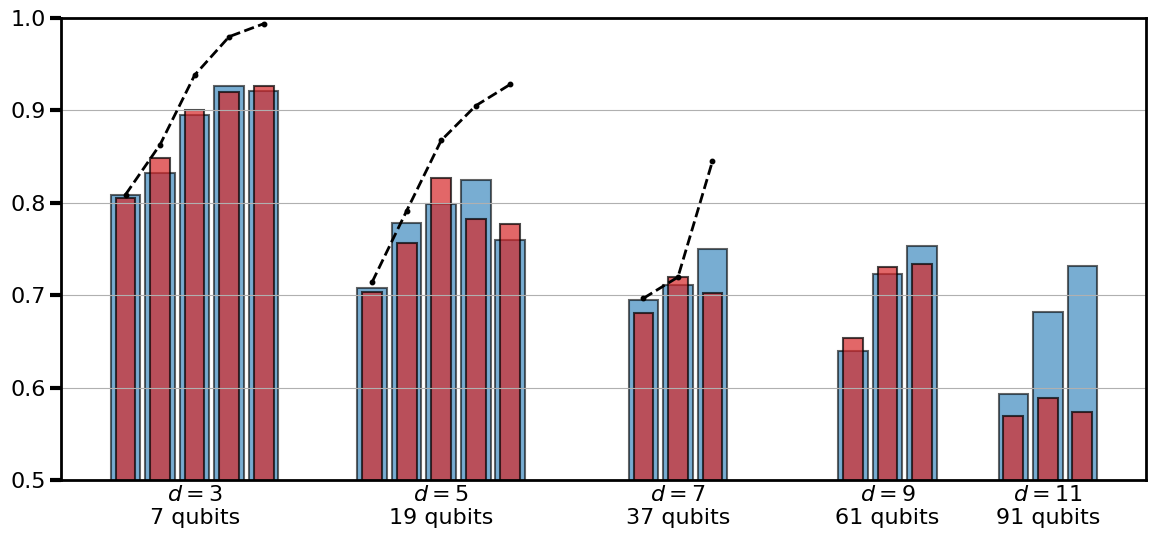

       code   p     shots   r MCM  r direct  r_ideal  n_sigma MCM  direct
   color_d3   3  500/500   0.8053    0.8080   0.8089         23.7    23.9
   color_d3   5  500/500   0.8487    0.8327   0.8630         27.0    25.8
   color_d3  10  500/500   0.9000    0.8953   0.9381         31.0    30.6
   color_d3  15  100/100   0.9200    0.9267   0.9797         14.5    14.8
   color_d3  20  500/500   0.9260    0.9213   0.9937         33.0    32.6
   color_d5   3  100/100   0.7033    0.7078   0.7143         12.2    12.5
   color_d5   5  100/100   0.7567    0.7778   0.7914         15.4    16.7
   color_d5  10  100/100   0.8267    0.7989   0.8675         19.6    17.9
   color_d5  15  100/100   0.7822    0.8244   0.9050         16.9    19.5
   color_d5  20  100/100   0.7767    0.7600   0.9281         16.6    15.6
   color_d7   3   50/10    0.6811    0.6944   0.6966         10.9     5.2
   color_d7   5   50/10    0.7200    0.7111   0.7195         13.2     5.7
   color_d7  10   50/10    0.7022    0

In [13]:
groups = panel("color_code",
               emulator={"mcm": ["20260316_1139"], "direct": ["20260316_1020"]},
               hardware={"mcm": ["20260316_1424", "20260330_1108", "20260825_1231"],
                         "direct": ["20260316_1419", "20260330_1108"]},
               order=["color_d3", "color_d5", "color_d7", "color_d9", "color_d11"])
code_bars(groups, positions=[0, 5, 10.5, 14.75, 18], name="fig6a_color_code_quantinuum.pdf")

### Fig. 6b - surface code, $d = 3, 5$ (Helios-1E) and $d = 7, 9$ (Helios-1)

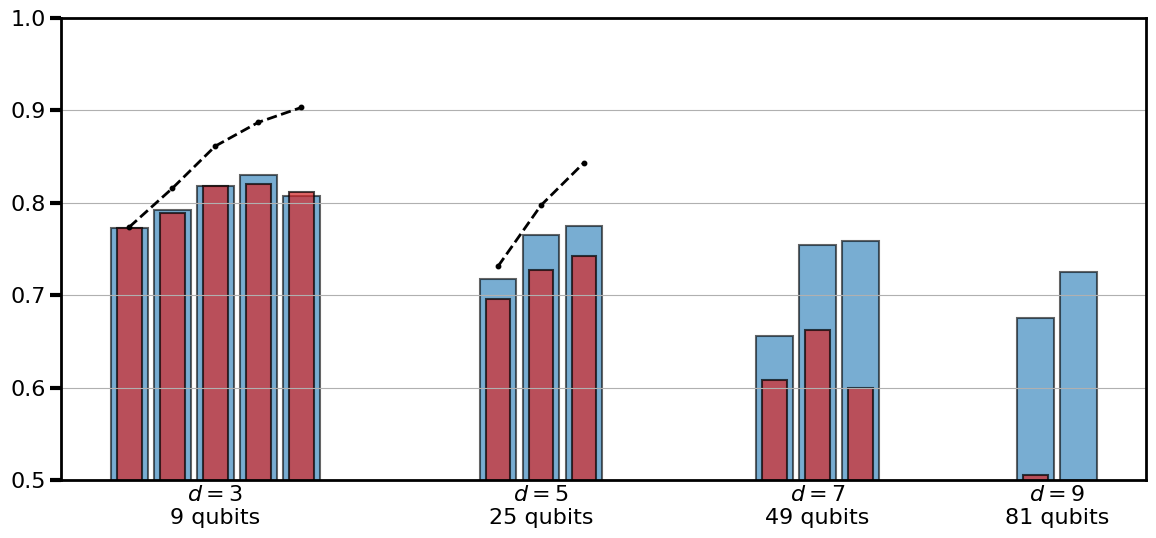

       code   p     shots   r MCM  r direct  r_ideal  n_sigma MCM  direct
 surface_d3   3  500/500   0.7722    0.7730   0.7737         34.4    34.5
 surface_d3   5  500/500   0.7888    0.7923   0.8155         36.5    37.0
 surface_d3  10  500/500   0.8185    0.8180   0.8613         40.3    40.2
 surface_d3  15  500/500   0.8200    0.8300   0.8870         40.5    41.7
 surface_d3  20  500/500   0.8113    0.8077   0.9031         39.4    38.9
 surface_d5   3  500/500   0.6955    0.7180   0.7311         42.8    47.8
 surface_d5   5  500/500   0.7268    0.7649   0.7972         49.7    58.0
 surface_d5  10  500/420   0.7428    0.7746   0.8434         53.2    55.1
 surface_d7   3   10/10    0.6083    0.6562      nan          4.7     6.8
 surface_d7   5   10/10    0.6625    0.7542      nan          7.1    11.1
 surface_d7  10   10/10    0.6000    0.7583      nan          4.4    11.3
 surface_d9   3   10/10    0.5050    0.6750      nan          0.3     9.9
 surface_d9   5   10/10    0.4800    0

In [14]:
groups = panel("surface_code",
               emulator={"mcm": ["20260306_1514", "20260309_1203", "20260310_1119"],
                         "direct": ["20260306_1621", "20260310_0729"]},
               hardware={"mcm": ["20260309_1631"], "direct": ["20260309_1642"]},
               order=["surface_d3", "surface_d5", "surface_d7", "surface_d9"])
code_bars(groups, positions=[0, 6, 10.5, 14.75], name="fig6b_surface_code_quantinuum.pdf")

### Fig. 6c - qLDPC codes, BB18 (Helios-1E) and BB30, BB48 (Helios-1)

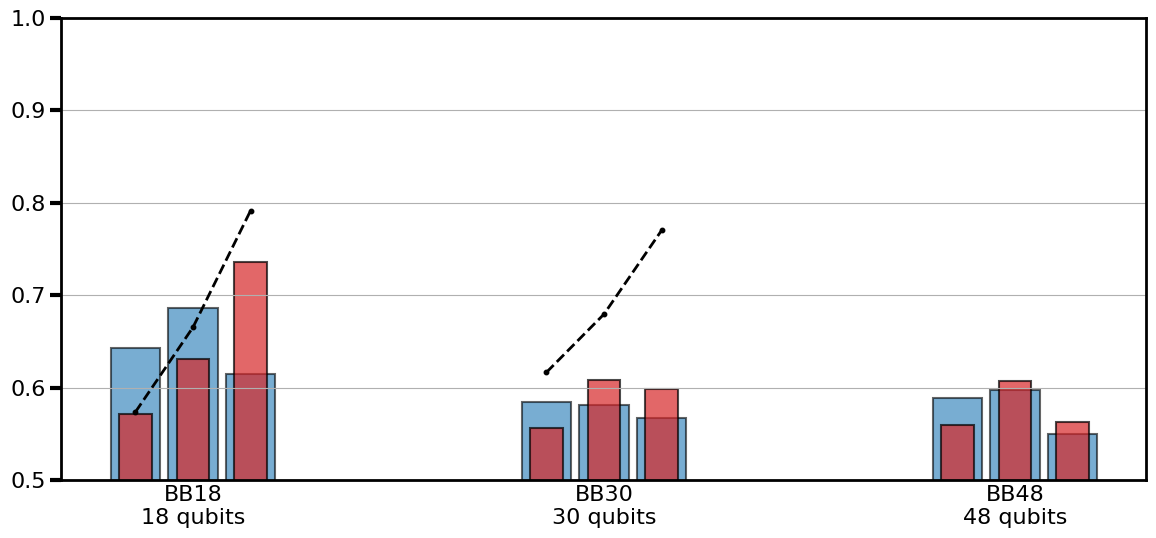

       code   p     shots   r MCM  r direct  r_ideal  n_sigma MCM  direct
       BB18   3  100/10    0.5714    0.6429   0.5736          5.3     3.4
       BB18   5  100/10    0.6307    0.6857   0.6652          9.8     4.4
       BB18  10  100/10    0.7357    0.6143   0.7913         17.6     2.7
       BB30   3   20/20    0.5558    0.5846   0.6164          2.5     3.9
       BB30   5   20/20    0.6077    0.5808   0.6794          4.9     3.7
       BB30  10   20/20    0.5981    0.5673   0.7700          4.5     3.1
       BB48   3   20/20    0.5591    0.5886      nan          3.5     5.3
       BB48   5   20/20    0.6068    0.5977      nan          6.3     5.8
       BB48  10   18/20    0.5631    0.5500      nan          3.6     3.0


In [15]:
groups = panel("qldpc",
               emulator={"mcm": ["20260629_0732"], "direct": ["20260629_1457"]},
               hardware={"mcm": ["20260702_0853"], "direct": ["20260702_0853"]},
               order=["BB18", "BB30", "BB48"])
code_bars(groups, positions=[0, 5, 10], name="fig6c_qldpc_quantinuum.pdf", slots=[3, 5, 10])

## 8. Fig. 7 - the shot budget: separating LR-QAOA from random guessing

A result is the mean of $S$ single-shot values of $r$. Random guessing gives $r_{\rm rand} = 1/2$ with spread
$\sigma_{\rm rand}(S) = \sqrt{\sum_c w_c^2 / S}\,/\,(E_{\max} - E_{\min})$. How often does the mean of $S$ shots of a
*noiseless* device clear $r_{\rm rand} + 3\sigma_{\rm rand}(S)$? That is the least budget any device needs to tell its
result apart from random guessing (`qecbench.shots`). The dashed line marks 95 %.

* **Fig. 7a** - surface code $d = 3$ and $d = 5$ (9 and 25 data qubits) at $p = 3$.
* **Fig. 7b** - BB qLDPC codes BB18, BB24 and BB30 (18, 24 and 30 data qubits) at $p = 3$.

**Data and what differs from the published panels.** No device data. The random threshold is exact, and so is the
noiseless single-shot distribution up to 25 data qubits (`lrqaoa.ideal_energy_distribution`: one probability per
energy level; the 24- and 25-qubit ones are kept in `data/references/ideal_energies.json`). BB30 is past the exact
limit, so its distribution is the energy histogram of the published 10 000-shot noiseless simulation, stored in the
same file by `scripts/import_legacy_codes.py --references`. The published panels resampled 500-shot (surface code)
and 10 000-shot (qLDPC) simulations and a 200 000-bitstring random pool instead. That moves the probabilities by a
few hundredths at most and leaves the shots needed for 95 % unchanged or one grid step apart; the cells below print
both.

In [16]:
from qecbench import CodePatch
from qecbench.shots import ideal_r_distribution, separation_probability, shots_to_separate


def separation_panel(patches, shots_grid, published, figsize, xticks, name, label, legend_loc="best"):
    # P(mean of S noiseless shots > r_rand + 3 sigma_rand(S)) against S, one line per code
    fig, ax = plt.subplots(figsize=figsize)
    print(f"{'code':>11} {'data qubits':>12} {'noiseless r':>12}   S = {shots_grid}")
    for k, patch in enumerate(patches):
        values, probabilities = ideal_r_distribution(patch, depth=3)
        separated = separation_probability(patch, values, probabilities, shots_grid, n_sigma=3, n_boot=20_000,
                                           seed=260708)
        ax.plot(shots_grid, separated, "-o", color=plt.get_cmap("Set1")(k), label=label(patch), markersize=5)
        print(f"{patch.code.name:>11} {patch.n_data:>12} {values @ probabilities:>12.4f}   {np.round(separated, 3)}"
              f"   -> 95% at S = {shots_to_separate(shots_grid, separated)}")
        print(f"{'published':>11} {'':>12} {'':>12}   {np.array(published[patch.code.name])}"
              f"   -> 95% at S = {shots_to_separate(shots_grid, published[patch.code.name])}")
    ax.axhline(0.95, color="k", ls="--", lw=1.1, label="95%")
    ax.legend(fontsize=10, loc=legend_loc)
    ax.grid(True, which="both", ls=":", alpha=0.45)
    ax.set_xticks(xticks, xticks)
    if SHOW_LABELS:
        ax.set(xlabel="shots $S$", ylabel=r"$P(\bar r > r_{\rm rand} + 3\sigma_{\rm rand})$")
    fig.savefig(FIGURES / name, transparent=True, bbox_inches="tight")
    plt.show()

### Fig. 7a - surface code, $d = 3, 5$

       code  data qubits  noiseless r   S = [5, 10, 20, 30]
 surface_d3            9       0.7737   [0.747 0.983 1.    1.   ]   -> 95% at S = 10
  published                             [0.725 0.975 1.    1.   ]   -> 95% at S = 10
 surface_d5           25       0.7311   [0.984 1.    1.    1.   ]   -> 95% at S = 5
  published                             [0.979 1.    1.    1.   ]   -> 95% at S = 5


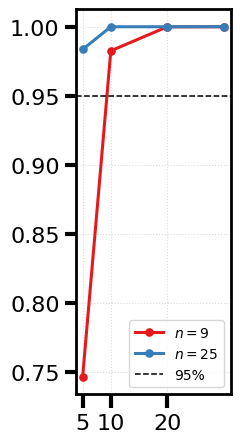

In [17]:
separation_panel([CodePatch(codes.surface_code(d)) for d in (3, 5)], shots_grid=[5, 10, 20, 30],
                 published={"surface_d3": [0.725, 0.975, 1, 1], "surface_d5": [0.979, 1, 1, 1]},
                 figsize=(2, 5), xticks=[5, 10, 20], name="fig7a_surface_code_shots_to_separate.pdf",
                 label=lambda patch: f"$n={patch.n_data}$", legend_loc="lower right")

### Fig. 7b - BB qLDPC codes, BB18, BB24, BB30

       code  data qubits  noiseless r   S = [5, 10, 20, 30, 50, 75, 100, 125, 150, 200]


       BB18           18       0.5736   [0.124 0.22  0.358 0.519 0.725 0.871 0.944 0.977 0.992 0.999]   -> 95% at S = 125
  published                             [0.119 0.211 0.352 0.477 0.728 0.868 0.934 0.978 0.988 0.998]   -> 95% at S = 125


       BB24           24       0.6051   [0.228 0.487 0.814 0.949 0.997 1.    1.    1.    1.    1.   ]   -> 95% at S = 50
  published                             [0.248 0.504 0.853 0.956 0.997 1.    1.    1.    1.    1.   ]   -> 95% at S = 30


       BB30           30       0.6164   [0.369 0.727 0.971 0.998 1.    1.    1.    1.    1.    1.   ]   -> 95% at S = 20
  published                             [0.372 0.727 0.96  0.998 1.    1.    1.    1.    1.    1.   ]   -> 95% at S = 20


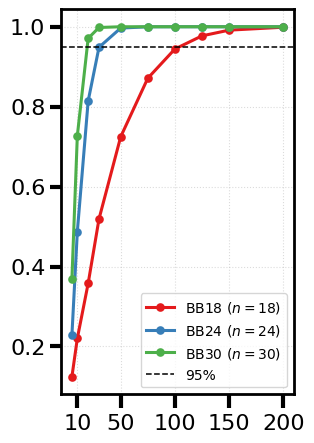

In [18]:
separation_panel([CodePatch(codes.bivariate_bicycle(name)) for name in ("BB18", "BB24", "BB30")],
                 shots_grid=[5, 10, 20, 30, 50, 75, 100, 125, 150, 200],
                 published={"BB18": [0.119, 0.211, 0.352, 0.477, 0.728, 0.868, 0.934, 0.978, 0.988, 0.998],
                            "BB24": [0.248, 0.504, 0.853, 0.956, 0.997, 1, 1, 1, 1, 1],
                            "BB30": [0.372, 0.727, 0.96, 0.998, 1, 1, 1, 1, 1, 1]},
                 figsize=(3, 5), xticks=[10, 50, 100, 150, 200], name="fig7b_qldpc_shots_to_separate.pdf",
                 label=lambda patch: f"{patch.code.name} ($n={patch.n_data}$)")

## 9. Fig. 8 - ranking devices: the shots it takes, and the surface code across machines

* **Fig. 8a** - how many shots per device LR-QAOA needs to rank two devices whose error rates differ by a factor of
  two, at $3\sigma$: $S^* = 9\,(\sigma_A^2 + \sigma_B^2)/(\mu_B - \mu_A)^2$, with $\mu$ and $\sigma$ the mean and spread of
  the single-shot $r$ (`shots.shots_to_rank`), against depth. Surface code $d = 3$ from noisy simulations (direct
  circuit, two-qubit depolarizing $\lambda$ after every CNOT, 50 000 shots per device and depth) and colour code
  $d = 5$ from a white-noise model, for $\lambda = 0.02/0.01$ and $0.002/0.001$. $S^*$ has a minimum in depth: too
  shallow and the two devices barely differ, too deep and both are near random.
* **Fig. 8b, 8c** - MCM $r_{\rm ovl}$ of the surface code $d = 3$ (9 data qubits) and $d = 5$ (25) against depth on
  H2-1, Helios-1 and IBM Phoenix, with the H2-1E and Helios-1E emulators (dashed). Neither Quantinuum machine ran
  $d = 3$ on hardware, and H2-1E never ran $d = 5$. IBM Phoenix is the best patch of the position scan
  (`benchmark_codes_ibm.ipynb`): anchor $(r_0, c_0) = (7, 4)$ for $d = 3$ and $(2, 4)$ for $d = 5$; the trapped-ion
  machines are all-to-all and have no patch to choose, so this favours Phoenix.

**Data.**
* 8a: `data/shot_budget/two_device_ranking.json` (`scripts/import_shot_budget.py`). For the surface code it holds
  the means and spreads of the noisy simulations, which is all $S^*$ needs (the samples were not kept). For the
  colour code it holds the model constant $c = \kappa_0(n)\,N_{\rm CX} = 17.77$ ($N_{\rm CX} = 66$ per layer) and the
  depths; the model distribution $A\,P_{\rm ideal} + (1 - A)\,P_{\rm random}$, $A = 2^{-c p \lambda}$, is recomputed from
  the exact noiseless and random distributions and reproduces the published curve. Here $\lambda$ is that model's
  parameter, counted per CNOT, not the per-edge $\lambda$ of Fig. 4 and 5.
* 8b, 8c: converted by `scripts/import_legacy_codes.py`, for each device and depth the run with the most shots
  (the earliest when tied), as the published panels chose. The IBM files store logical labels; the conversion puts
  them back on the physical patch (`--anchor`), which `layout.surface_code_placements` reproduces qubit for qubit
  from the position scan's layout.

| panel | device | run files (`data/results/<device>/surface_code/mcm/`) | shots |
|---|---|---|---|
| 8b | H2-1E | `20260820_0707` | 500 |
| 8b | Helios-1E | `20260306_1514` ($p = 3, 5$), `20260306_1518` ($p = 10$) | 500 |
| 8b | ibm_phoenix | `20260909_1631` | 1000 |
| 8c | H2-1 | `20260820_0736` | 50 |
| 8c | Helios-1 | `20260825_1229` | 50 |
| 8c | Helios-1E | `20260309_1203` | 500 |
| 8c | ibm_phoenix | `20260909_1619` | 1000 |

**What differs from the published panels.** The values of $r$ are unchanged. $r_{\rm ovl}$ uses the exact
$r_{\rm ideal}$ and $r_{\rm rand} = 1/2$ where the published panels used sampled simulations (e.g. $d = 3$, $p = 3$: 0.7737
against 0.7717) and a bootstrapped $r_{\rm rand} \approx 0.497$, which moves $r_{\rm ovl}$ by up to about 0.03; the cells
print both.

                       curve  S* (3 sigma) by depth
       surface d=3 0.02/0.01  p=3: 177, p=5: 97, p=8: 90, p=12: 136
     surface d=3 0.002/0.001  p=3: 4658, p=10: 280, p=25: 95, p=42: 67, p=60: 58, p=85: 64


colour d=5 (model) 0.02/0.01  p=1: 8396, p=3: 337, p=5: 151, p=7: 123, p=11: 147, p=15: 244


colour d=5 (model) 0.002/0.001  p=3: 10029, p=12: 333, p=28: 132, p=49: 94, p=73: 90, p=106: 114, p=146: 193


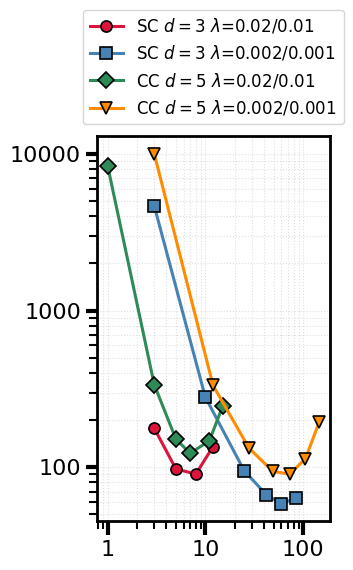

In [19]:
from qecbench.shots import (moments, random_r_distribution, shots_to_rank, white_noise_distribution)

budget = json.loads((ROOT / "data" / "shot_budget" / "two_device_ranking.json").read_text())

fig, ax = plt.subplots(figsize=(3, 5))
print(f"{'curve':>28}  S* (3 sigma) by depth")
for pair, colour, marker in (("0.02/0.01", "crimson", "o"), ("0.002/0.001", "steelblue", "s")):
    data = budget["surface_d3"]["pairs"][pair]["moments"]
    depths = sorted(int(p) for p in data)
    s_star = [shots_to_rank(data[str(p)]["mean_worse"], data[str(p)]["std_worse"],
                            data[str(p)]["mean_better"], data[str(p)]["std_better"], z=3) for p in depths]
    ax.plot(depths, s_star, marker + "-", color=colour, ms=8, mec="k", label=rf"SC $d=3$ $\lambda$={pair}")
    print(f"{'surface d=3 ' + pair:>28}  " + ", ".join(f"p={p}: {s:.0f}" for p, s in zip(depths, s_star)))

model = budget["color_d5_model"]
patch = CodePatch(codes.color_code(5), kind="direct")
rand_values, rand_probabilities = random_r_distribution(patch)
for pair, colour, marker in (("0.02/0.01", "seagreen", "D"), ("0.002/0.001", "darkorange", "v")):
    spec = model["pairs"][pair]
    s_star = []
    for p in spec["depths"]:
        values, ideal = ideal_r_distribution(patch, p)
        worse, better = (moments(values, white_noise_distribution(ideal, rand_probabilities, 2.0 ** (-model["c"] * p * lam)))
                         for lam in (spec["lambda_worse"], spec["lambda_better"]))
        s_star.append(shots_to_rank(*worse, *better, z=3))
    ax.plot(spec["depths"], s_star, marker + "-", color=colour, ms=8, mec="k", label=rf"CC $d=5$ $\lambda$={pair}")
    print(f"{'colour d=5 (model) ' + pair:>28}  " + ", ".join(f"p={p}: {s:.0f}" for p, s in zip(spec["depths"], s_star)))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks([1, 10, 100], [1, 10, 100])
ax.set_yticks([100, 1000, 10000], [100, 1000, 10000])
ax.legend(fontsize=12, loc="upper center", bbox_to_anchor=(0.5, 1.35))
ax.grid(True, which="both", ls=":", alpha=0.4)
if SHOW_LABELS:
    ax.set(xlabel="LR-QAOA depth $p$", ylabel=r"$S^\ast$ ($3\sigma$)")
fig.savefig(FIGURES / "fig8a_two_device_ranking_shots.pdf", transparent=True, bbox_inches="tight")
plt.show()

In [20]:
FIG8_DEPTHS = [3, 5, 10]
FIG8_DEVICES = {                      # device: (label, Set1 colour, marker, emulator)
    "H2-1": ("H2-1", 4, "o", False), "H2-1E": ("H2-1E", 4, "s", True),
    "Helios-1": ("Helios-1", 3, "o", False), "Helios-1E": ("Helios-1E", 3, "s", True),
    "ibm_phoenix": ("ibm_phoenix (best patch)", 1, "X", False),
}


def mcm_overlap_panel(code_name, device_runs, published, name):
    # MCM r_ovl against depth per device; the table adds shot noise and the published values
    fig, ax = plt.subplots(figsize=(2, 4))
    print(f"{code_name}: r_ovl (1 = noiseless, 0 = random), with 1 sigma shot noise; published below each row")
    print(f"{'device':>26}{'shots':>7}" + "".join(f"{'p=' + str(p):>16}" for p in FIG8_DEPTHS))
    for device, stamps in device_runs.items():
        label, colour, marker, emulator = FIG8_DEVICES[device]
        (by_depth,) = [by for patch, by in runs(device, stamps, "mcm", "surface_code").items()
                       if patch.code.name == code_name]
        ps = [p for p in FIG8_DEPTHS if p in by_depth]
        ovl = [by_depth[p]["r_ovl"] for p in ps]
        err = [by_depth[p]["r_err"] / (by_depth[p]["r_ideal"] - by_depth[p]["r_rand"]) for p in ps]
        ax.plot(ps, ovl, marker=marker, color=plt.get_cmap("Set1")(colour), linestyle="--" if emulator else "-",
                markersize=8, markeredgecolor="black", label=label + (" (emu)" if emulator else ""))
        shots = "/".join(str(v) for v in sorted({by_depth[p]["shots"] for p in ps}))
        print(f"{label:>26}{shots:>7}" + "".join(f"  {o:.3f}+-{e:.3f}" for o, e in zip(ovl, err)))
        print(f"{'published':>26}{'':>7}" + "".join(f"{v:>16.3f}" for v in published[device]))
    ax.set_xticks(FIG8_DEPTHS)
    ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, 1.32), ncol=1)
    if SHOW_LABELS:
        ax.set(xlabel="$p$", ylabel=r"$r_{\rm ovl}$")
    fig.savefig(FIGURES / name, transparent=True, bbox_inches="tight")
    plt.show()

### Fig. 8b - surface code $d = 3$ (9 data qubits), MCM

surface_d3: r_ovl (1 = noiseless, 0 = random), with 1 sigma shot noise; published below each row
                    device  shots             p=3             p=5            p=10
                     H2-1E    500  0.973+-0.025  0.944+-0.017  0.875+-0.018
                 published                  0.980           0.947           0.885
                 Helios-1E    500  0.995+-0.024  0.915+-0.019  0.895+-0.016
                 published                  1.002           0.919           0.905
  ibm_phoenix (best patch)   1000  0.481+-0.021  0.364+-0.018  0.240+-0.016
                 published                  0.490           0.372           0.249


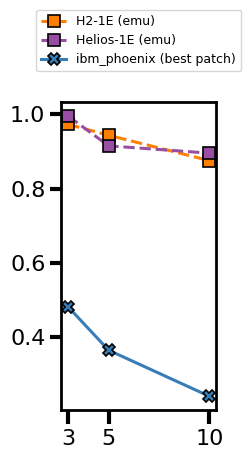

In [21]:
mcm_overlap_panel("surface_d3",
                  {"H2-1E": ["20260820_0707"], "Helios-1E": ["20260306_1514", "20260306_1518"],
                   "ibm_phoenix": ["20260909_1631"]},
                  published={"H2-1E": [0.980, 0.947, 0.885], "Helios-1E": [1.002, 0.919, 0.905],
                             "ibm_phoenix": [0.490, 0.372, 0.249]},
                  name="fig8b_mcm_rovl_surface_d3.pdf")

### Fig. 8c - surface code $d = 5$ (25 data qubits), MCM

surface_d5: r_ovl (1 = noiseless, 0 = random), with 1 sigma shot noise; published below each row
                    device  shots             p=3             p=5            p=10
                      H2-1     50  0.750+-0.054  0.631+-0.038  0.609+-0.036
                 published                  0.759           0.625           0.611
                  Helios-1     50  1.017+-0.057  0.833+-0.037  0.733+-0.043
                 published                  1.030           0.826           0.736
                 Helios-1E    500  0.846+-0.020  0.763+-0.014  0.707+-0.013
                 published                  0.857           0.757           0.710
  ibm_phoenix (best patch)   1000  0.208+-0.014  0.214+-0.012  0.153+-0.010
                 published                  0.210           0.211           0.153


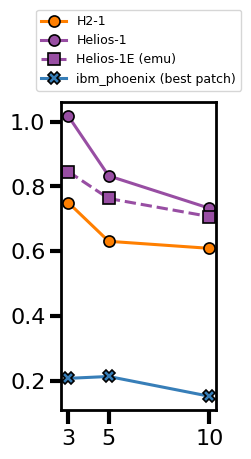

In [22]:
mcm_overlap_panel("surface_d5",
                  {"H2-1": ["20260820_0736"], "Helios-1": ["20260825_1229"], "Helios-1E": ["20260309_1203"],
                   "ibm_phoenix": ["20260909_1619"]},
                  published={"H2-1": [0.759, 0.625, 0.611], "Helios-1": [1.030, 0.826, 0.736],
                             "Helios-1E": [0.857, 0.757, 0.710], "ibm_phoenix": [0.210, 0.211, 0.153]},
                  name="fig8c_mcm_rovl_surface_d5.pdf")

## 10. Fig. 9 - LR-QAOA against the logical error rate of a real memory, patch by patch

The `ibm_phoenix` surface-code position scan of 14 September 2026 ran, on each of 11 $d = 3$ and 8 $d = 5$ patches of
the chip, two experiments **on the same physical qubits**: the MCM LR-QAOA benchmark at depths $p = 1, 2, 3, 5, 7, 10$
(1000 shots) and a surface-code **Z memory** at $R = p$ rounds (4000 shots), decoded by matching on the stim detector
error model (`benchmark_qec_memory.ipynb`, `qecbench.memory`). One figure per distance: $x$ is $r_{\rm ovl}$ at depth $p$,
$y$ the logical error rate after $R = p$ rounds (marker = $p = R$). The two patches with the best mean $r_{\rm ovl}$ are
drawn as trajectories, joined in order of depth; the other patches are grey. A patch LR-QAOA ranks well should also
keep a low logical error as both circuits deepen.

**Data.** Re-harvested from the scan's IBM jobs (read-only) by `scripts/import_position_scan.py` into
`data/results/ibm_phoenix/surface_code/mcm/20260914_0941_ibm_phoenix_surface_code_mcm.json` (LR-QAOA) and
`.../surface_code/memory/20260914_0941_ibm_phoenix_surface_code_memory.json` (memory, every shot's raw syndrome and data
bits, both bases). Each patch is rebuilt from its anchor; the placement reproduces the scan's layout qubit for qubit,
and the scan's calibration snapshot of every patch is kept in the run header. The logical error rates are decoded
again here from the raw shots and equal the published ones exactly (all 228 circuits). $r_{\rm ovl}$ uses the exact
noiseless reference and $r_{\rm rand} = 1/2$ instead of the sampled ones, which moves it by up to about 0.02 and leaves
the two highlighted patches unchanged; the cell prints both.

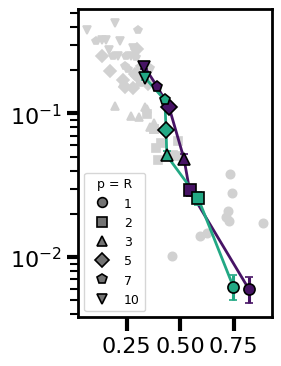

surface code d = 3: 2 of 11 patches, p = R = [1, 2, 3, 5, 7, 10]   (r_ovl / Z logical error)
     (6, 3) mean r_ovl 0.510 | p1: 0.821/0.0060  p2: 0.544/0.0293  p3: 0.518/0.0485  p5: 0.448/0.1103  p7: 0.394/0.1530  p10: 0.333/0.2110
   published                  | p1: 0.812/0.0060  p2: 0.543/0.0293  p3: 0.527/0.0485  p5: 0.455/0.1103  p7: 0.399/0.1530  p10: 0.342/0.2110
     (7, 2) mean r_ovl 0.495 | p1: 0.748/0.0063  p2: 0.584/0.0257  p3: 0.438/0.0510  p5: 0.434/0.0767  p7: 0.429/0.1240  p10: 0.337/0.1762
   published                  | p1: 0.740/0.0063  p2: 0.582/0.0257  p3: 0.447/0.0510  p5: 0.441/0.0767  p7: 0.434/0.1240  p10: 0.346/0.1762


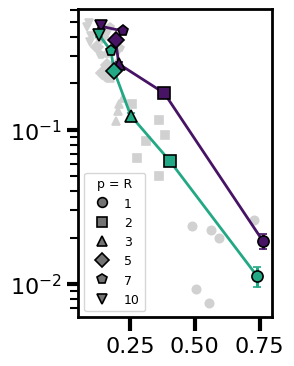

surface code d = 5: 2 of 8 patches, p = R = [1, 2, 3, 5, 7, 10]   (r_ovl / Z logical error)
     (3, 5) mean r_ovl 0.318 | p1: 0.763/0.0190  p2: 0.382/0.1725  p3: 0.206/0.2667  p5: 0.194/0.3837  p7: 0.224/0.4360  p10: 0.138/0.4675
   published                  | p1: 0.745/0.0190  p2: 0.378/0.1725  p3: 0.208/0.2667  p5: 0.191/0.3837  p7: 0.224/0.4360  p10: 0.138/0.4675
     (1, 4) mean r_ovl 0.315 | p1: 0.740/0.0112  p2: 0.403/0.0628  p3: 0.253/0.1232  p5: 0.188/0.2405  p7: 0.176/0.3255  p10: 0.132/0.4080
   published                  | p1: 0.723/0.0112  p2: 0.399/0.0628  p3: 0.255/0.1232  p5: 0.186/0.2405  p7: 0.176/0.3255  p10: 0.132/0.4080


In [23]:
from matplotlib.lines import Line2D

from qecbench import memory as mem

SCAN = "20260914_0941"
N_SHOW = 2
FIG9_PUBLISHED = {   # published trajectories (r_ovl / logical error) of the highlighted patches
    (3, (6, 3)): [(0.812, 0.0060), (0.543, 0.0293), (0.527, 0.0485), (0.455, 0.1103), (0.399, 0.1530), (0.342, 0.2110)],
    (3, (7, 2)): [(0.740, 0.0063), (0.582, 0.0257), (0.447, 0.0510), (0.441, 0.0767), (0.434, 0.1240), (0.346, 0.1762)],
    (5, (3, 5)): [(0.745, 0.0190), (0.378, 0.1725), (0.208, 0.2667), (0.191, 0.3837), (0.224, 0.4360), (0.138, 0.4675)],
    (5, (1, 4)): [(0.723, 0.0112), (0.399, 0.0628), (0.255, 0.1232), (0.186, 0.2405), (0.176, 0.3255), (0.132, 0.4080)],
}

overlap = runs("ibm_phoenix", [SCAN], "mcm", "surface_code")
logical = mem.load_results(RESULTS, "ibm_phoenix", files={f"{SCAN}_ibm_phoenix_surface_code_memory.json"}, bases=["Z"])


def anchor(patch):
    # data qubit (0, 0) sits at lattice site (r0, c0) of the 12 x 10 chip
    return divmod(patch.data_qubits[0], 10)


for d in (3, 5):
    rows = {anchor(p): (by, logical[p]["Z"]) for p, by in overlap.items() if p.code.name == f"surface_d{d}"}
    depths = sorted(set.intersection(*(set(by) & set(mem_by) for by, mem_by in rows.values())))
    markers = dict(zip(depths, "os^Dpv"))
    mean_ovl = {k: np.mean([by[p]["r_ovl"] for p in depths]) for k, (by, _) in rows.items()}
    chosen = sorted(rows, key=lambda k: -mean_ovl[k])[:N_SHOW]

    fig, ax = plt.subplots(figsize=(2.5, 4))
    for k, (by, mem_by) in rows.items():
        if k not in chosen:
            for p in depths:
                ax.plot(by[p]["r_ovl"], mem_by[p]["rate"], markers[p], ms=6, color="0.82", zorder=1)
    for colour, k in zip(plt.cm.viridis(np.linspace(0.05, 0.6, len(chosen))), chosen):
        by, mem_by = rows[k]
        X = [by[p]["r_ovl"] for p in depths]
        Y = [mem_by[p]["rate"] for p in depths]
        E = [mem_by[p]["err"] for p in depths]
        ax.plot(X, Y, "-", color=colour, lw=2, zorder=2)
        for x, y, e, p in zip(X, Y, E, depths):
            ax.errorbar(x, y, yerr=e, fmt=markers[p], ms=8, color=colour, capsize=3, markeredgecolor="black", zorder=3)
    ax.set_yscale("log")
    ax.legend(handles=[Line2D([], [], ls="", marker=markers[p], ms=7, color="0.45", markeredgecolor="black", label=f"{p}")
                       for p in depths], title="p = R", fontsize=9, title_fontsize=9, loc="lower left", frameon=True)
    if SHOW_LABELS:
        ax.set(xlabel=r"$r_{\rm ovl}$ at depth $p$", ylabel="logical error rate at $R = p$")
    fig.savefig(FIGURES / f"fig9_position_trajectories_surface_d{d}.pdf", transparent=True, bbox_inches="tight")
    plt.show()

    print(f"surface code d = {d}: {N_SHOW} of {len(rows)} patches, p = R = {depths}   (r_ovl / Z logical error)")
    for k in chosen:
        by, mem_by = rows[k]
        print(f"   {str(k):>8} mean r_ovl {mean_ovl[k]:.3f} | "
              + "  ".join(f"p{p}: {by[p]['r_ovl']:.3f}/{mem_by[p]['rate']:.4f}" for p in depths))
        if (d, k) in FIG9_PUBLISHED:
            print(f"   {'published':>8}                  | "
                  + "  ".join(f"p{p}: {x:.3f}/{y:.4f}" for p, (x, y) in zip(depths, FIG9_PUBLISHED[(d, k)])))